# RNA viromics of Southern California wastewater
### Author: Shawn Higdon
### Date: July 2, 2026

> This notebook presents a reproducible reanalysis of selected metatranscriptomic wastewater samples from Rothman et al., focusing on preprocessing, QC, host filtering, taxonomic composition, viral relative abundance, and SARS-CoV-2 signal across enriched and unenriched samples. The computational preprocessing and table generation were performed with **Snakemake**, while this notebook reads workflow outputs to generate figures and biological interpretations. __*The directed acyclic graph is visualized below:*__

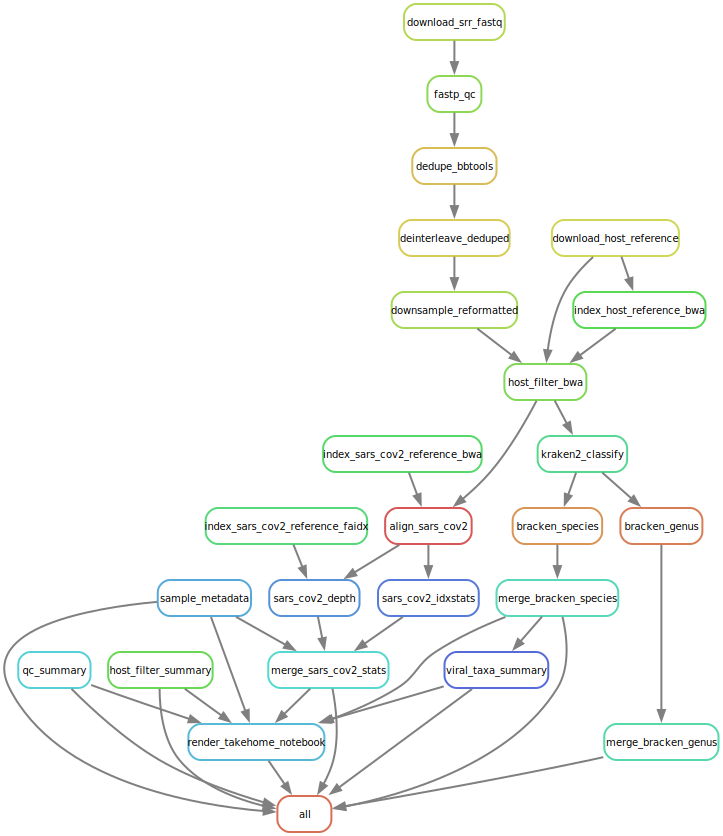

In [98]:
from IPython.display import SVG, display
display(SVG(filename="../../misc/workflow_rulegraph.svg"))

In [94]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 120

In [95]:
# set dir variables
from pathlib import Path

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parents[1]
SUMMARY_DIR = PROJECT_ROOT / "results" / "summary"
TAX_DIR = PROJECT_ROOT / "results" / "taxonomy" / "merged"
SARS_DIR = PROJECT_ROOT / "results" / "sars_cov2"

print("Notebook dir:", NOTEBOOK_DIR)
print("Project root:", PROJECT_ROOT)
print("Summary dir:", SUMMARY_DIR)
print("Tax dir:", TAX_DIR)
print("Sars dir:", SARS_DIR)

assert SUMMARY_DIR.exists(), f"Missing summary directory: {SUMMARY_DIR}"

Notebook dir: /Users/shigdon/latch_bio/wastewater-viromics-takehome/workflow/notebooks
Project root: /Users/shigdon/latch_bio/wastewater-viromics-takehome
Summary dir: /Users/shigdon/latch_bio/wastewater-viromics-takehome/results/summary
Tax dir: /Users/shigdon/latch_bio/wastewater-viromics-takehome/results/taxonomy/merged
Sars dir: /Users/shigdon/latch_bio/wastewater-viromics-takehome/results/sars_cov2


In [5]:
# read summary tables
meta = pd.read_csv(SUMMARY_DIR / "sample_metadata.tsv", sep="\t")
qc = pd.read_csv(SUMMARY_DIR / "qc_summary.tsv", sep="\t")
host = pd.read_csv(SUMMARY_DIR / "host_filter_summary.tsv", sep="\t")
viral = pd.read_csv(SUMMARY_DIR / "viral_taxa_summary.tsv", sep="\t")

species_path = TAX_DIR / "bracken_species_counts.tsv"
genus_path = TAX_DIR / "bracken_genus_counts.tsv"

species = pd.read_csv(species_path, sep="\t") if species_path.exists() else None
genus = pd.read_csv(genus_path, sep="\t") if genus_path.exists() else None

In [7]:
# sanity check on loaded tables
display(meta.head())
display(qc.head())
display(host.head())
display(viral.head())

print("meta:", meta.shape)
print("qc:", qc.shape)
print("host:", host.shape)
print("viral:", viral.shape)

print("species table exists:", species is not None)
print("genus table exists:", genus is not None)

,sample,site,date,treatment,is_enriched
0,HTP_2020-11-03_enriched,HTP,2020-11-03,enriched,True
1,HTP_2020-11-03_unenriched,HTP,2020-11-03,unenriched,False
2,HTP_2020-11-24_enriched,HTP,2020-11-24,enriched,True
3,HTP_2020-11-24_unenriched,HTP,2020-11-24,unenriched,False
4,HTP_2020-12-04_enriched,HTP,2020-12-04,enriched,True


,sample,reads_before,reads_after,reads_retained_fraction,bases_before,bases_after,bases_retained_fraction,read1_mean_length_before,read2_mean_length_before,read1_mean_length_after,...,gc_content_after,passed_filter_reads,low_quality_reads,too_many_N_reads,adapter_dimer_reads,too_short_reads,too_long_reads,duplication_rate,adapter_trimmed_reads,adapter_trimmed_bases
0,HTP_2020-11-03_enriched,2146302,2142140,0.998061,216776502,184670772,0.851895,101,101,86,...,0.488522,2142140,4110,52,0,0,0,0.178651,901556,31692100
1,HTP_2020-11-03_unenriched,23069046,23021664,0.997946,2329973646,1973424678,0.846973,101,101,85,...,0.491163,23021664,45368,2014,0,0,0,0.379375,9683904,351862258
2,HTP_2020-11-24_enriched,2958648,2953142,0.998139,298823448,254600738,0.852011,101,101,86,...,0.480171,2953142,5416,90,0,0,0,0.201971,1248094,43679242
3,HTP_2020-11-24_unenriched,22091754,22046204,0.997938,2231267154,1875716082,0.840651,101,101,85,...,0.484783,22046204,43556,1994,0,0,0,0.378842,9663696,351056658
4,HTP_2020-12-04_enriched,2529648,2524470,0.997953,255494448,217033802,0.849466,101,101,85,...,0.497717,2524470,5096,82,0,0,0,0.218541,1094616,37944932


,sample,bam,total_reads,mapped_reads,unmapped_reads,both_mates_unmapped,mapped_fraction,unmapped_fraction,both_mates_unmapped_fraction
0,HTP_2020-11-03_enriched,results/host_filter/bwa/HTP_2020-11-03_enriche...,115592,39406,76186,76022,0.340906,0.659094,0.657675
1,HTP_2020-11-03_unenriched,results/host_filter/bwa/HTP_2020-11-03_unenric...,114734,35020,79714,79572,0.305228,0.694772,0.693535
2,HTP_2020-11-24_enriched,results/host_filter/bwa/HTP_2020-11-24_enriche...,115580,40758,74822,74694,0.352639,0.647361,0.646254
3,HTP_2020-11-24_unenriched,results/host_filter/bwa/HTP_2020-11-24_unenric...,115669,37749,77920,77796,0.326354,0.673646,0.672574
4,HTP_2020-12-04_enriched,results/host_filter/bwa/HTP_2020-12-04_enriche...,115049,40190,74859,74718,0.349329,0.650671,0.649445


,sample,site,date,treatment,taxonomy_lvl,taxonomy_id,name,reads,viral_total_reads,relative_abundance,is_viral,is_sars_cov_2
0,HTP_2020-11-03_enriched,HTP,2020-11-03,enriched,S,3432872,Tobamovirus fructirugosum,4742.0,10136.0,0.467837,True,False
1,HTP_2020-11-03_enriched,HTP,2020-11-03,enriched,S,3432895,Tobamovirus viridimaculae,1585.0,10136.0,0.156373,True,False
2,HTP_2020-11-03_enriched,HTP,2020-11-03,enriched,S,3432892,Tobamovirus tomatotessellati,1227.0,10136.0,0.121054,True,False
3,HTP_2020-11-03_enriched,HTP,2020-11-03,enriched,S,3432865,Tobamovirus capsici,1215.0,10136.0,0.119870,True,False
4,HTP_2020-11-03_enriched,HTP,2020-11-03,enriched,S,3432877,Tobamovirus maculatessellati,462.0,10136.0,0.045580,True,False


meta: (10, 5)
qc: (10, 26)
host: (10, 9)
viral: (230, 12)
species table exists: True
genus table exists: True


## Sample selection and SRA provenance

> This analysis uses a curated set of 10 HTP wastewater libraries (5 dates × enriched/unenriched) defined reproducibly from SRA metadata. SRA RunInfo for BioProject PRJNA729801 was fetched and filtered to HTP runs (`scripts/fetch_sra_runinfo_htp.sh`, output `metadata/PRJNA729801_htp_.filtered.csv`). An R script (`scripts/make_samples_htp.R`) then parsed this table, selected the desired date/treatment pairs, and wrote the final manifest `config/samples_htp.csv`, which Snakemake uses as the single source of truth for all downstream analysis.

> I selected consecutive wastewater influent sampling dates from a single treatment plant and retained paired enriched and unenriched libraries to compare treatment effects across time. The Snakemake workflow performed fastp-based quality filtering, deduplication/reformatting, downsampling, host filtering, and taxonomic summarization before this notebook loaded the resulting summary tables for interpretation.

In [8]:
# Sample design table
meta["date"] = pd.to_datetime(meta["date"])
meta = meta.sort_values(["date", "treatment"])

display(meta)

,sample,site,date,treatment,is_enriched
0,HTP_2020-11-03_enriched,HTP,2020-11-03,enriched,True
1,HTP_2020-11-03_unenriched,HTP,2020-11-03,unenriched,False
2,HTP_2020-11-24_enriched,HTP,2020-11-24,enriched,True
3,HTP_2020-11-24_unenriched,HTP,2020-11-24,unenriched,False
4,HTP_2020-12-04_enriched,HTP,2020-12-04,enriched,True
5,HTP_2020-12-04_unenriched,HTP,2020-12-04,unenriched,False
6,HTP_2020-12-22_enriched,HTP,2020-12-22,enriched,True
7,HTP_2020-12-22_unenriched,HTP,2020-12-22,unenriched,False
8,HTP_2021-01-03_enriched,HTP,2021-01-03,enriched,True
9,HTP_2021-01-03_unenriched,HTP,2021-01-03,unenriched,False


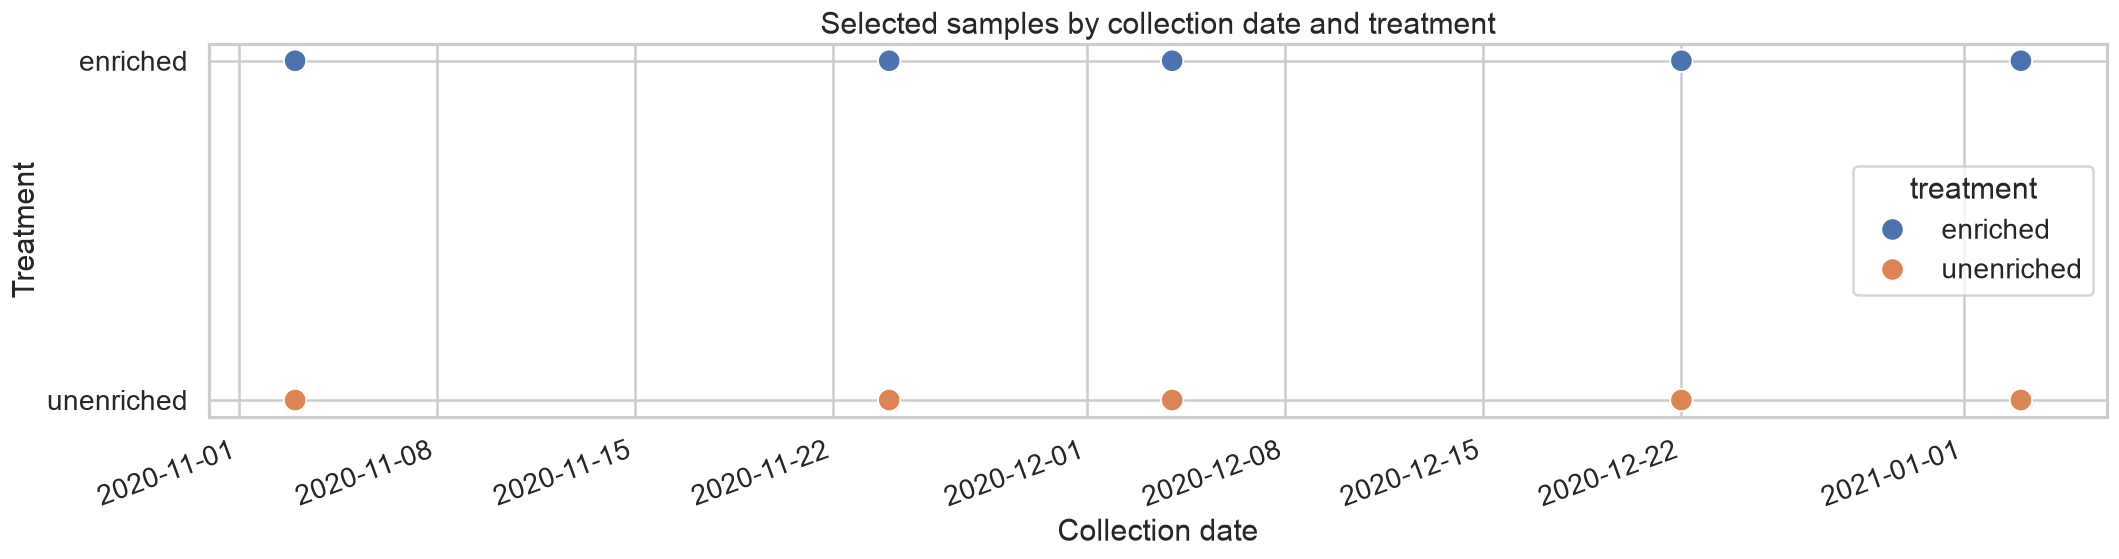

In [24]:
# Sample timeline plot
plt.figure(figsize=(18, 5))
sns.scatterplot(
    data=meta,
    x="date",
    y="treatment",
    hue="treatment",
    s=180
)
plt.title("Selected samples by collection date and treatment")
plt.xticks(rotation=20, ha="right")
plt.xlabel("Collection date")
plt.ylabel("Treatment")
plt.tight_layout()
plt.show()

### Sample Selection MCQ

__Why is it important to compare enriched and unenriched wastewater libraries collected on the same dates from the same plant?__

> A) It isolates treatment-associated differences from site-to-site variation.  
> B) It guarantees identical viral abundances in both libraries.  
> C) It removes the need for quality control.  
> D) It makes host filtering unnecessary.

## Quality Contol (QC)

> Quality control used the **fastp** toolkit to perform adapter trimming, quality filtering, and per-read base quality assessment for all selected libraries. `fastp` is a good choice for this step because it combines efficient, multithreaded trimming with comprehensive HTML/JSON reports, allowing rapid inspection of read retention, quality score distributions, and overrepresented sequences in a single pass. Quality control assessed whether sequencing reads were retained at high rates after trimming and whether per-sample metrics were sufficient for downstream wastewater viromics analysis. In metatranscriptomic workflows, this step is important because poor-quality or adapter-contaminated reads can distort both taxonomic profiles and variant analyses.

In [14]:
# Merge metadata into QC
qc = qc.merge(
    meta[["sample", "date", "treatment", "site", "is_enriched"]],
    on="sample",
    how="left"
)
qc = qc.sort_values(["date", "treatment"])

display(qc)

,sample,reads_before,reads_after,reads_retained_fraction,bases_before,bases_after,bases_retained_fraction,read1_mean_length_before,read2_mean_length_before,read1_mean_length_after,...,site_x,is_enriched_x,date_y,treatment_y,site_y,is_enriched_y,date,treatment,site,is_enriched
0,HTP_2020-11-03_enriched,2146302,2142140,0.998061,216776502,184670772,0.851895,101,101,86,...,HTP,True,2020-11-03,enriched,HTP,True,2020-11-03,enriched,HTP,True
1,HTP_2020-11-03_unenriched,23069046,23021664,0.997946,2329973646,1973424678,0.846973,101,101,85,...,HTP,False,2020-11-03,unenriched,HTP,False,2020-11-03,unenriched,HTP,False
2,HTP_2020-11-24_enriched,2958648,2953142,0.998139,298823448,254600738,0.852011,101,101,86,...,HTP,True,2020-11-24,enriched,HTP,True,2020-11-24,enriched,HTP,True
3,HTP_2020-11-24_unenriched,22091754,22046204,0.997938,2231267154,1875716082,0.840651,101,101,85,...,HTP,False,2020-11-24,unenriched,HTP,False,2020-11-24,unenriched,HTP,False
4,HTP_2020-12-04_enriched,2529648,2524470,0.997953,255494448,217033802,0.849466,101,101,85,...,HTP,True,2020-12-04,enriched,HTP,True,2020-12-04,enriched,HTP,True
5,HTP_2020-12-04_unenriched,21749208,21704706,0.997954,2196670008,1825957420,0.831239,101,101,84,...,HTP,False,2020-12-04,unenriched,HTP,False,2020-12-04,unenriched,HTP,False
6,HTP_2020-12-22_enriched,2596840,2591128,0.997800,262280840,225386036,0.859331,101,101,86,...,HTP,True,2020-12-22,enriched,HTP,True,2020-12-22,enriched,HTP,True
7,HTP_2020-12-22_unenriched,17723052,17692114,0.998254,1790028252,1432840284,0.800457,101,101,80,...,HTP,False,2020-12-22,unenriched,HTP,False,2020-12-22,unenriched,HTP,False
8,HTP_2021-01-03_enriched,1980758,1976752,0.997978,200056558,170009314,0.849806,101,101,86,...,HTP,True,2021-01-03,enriched,HTP,True,2021-01-03,enriched,HTP,True
9,HTP_2021-01-03_unenriched,19252914,19218084,0.998191,1944544314,1607732216,0.826791,101,101,83,...,HTP,False,2021-01-03,unenriched,HTP,False,2021-01-03,unenriched,HTP,False


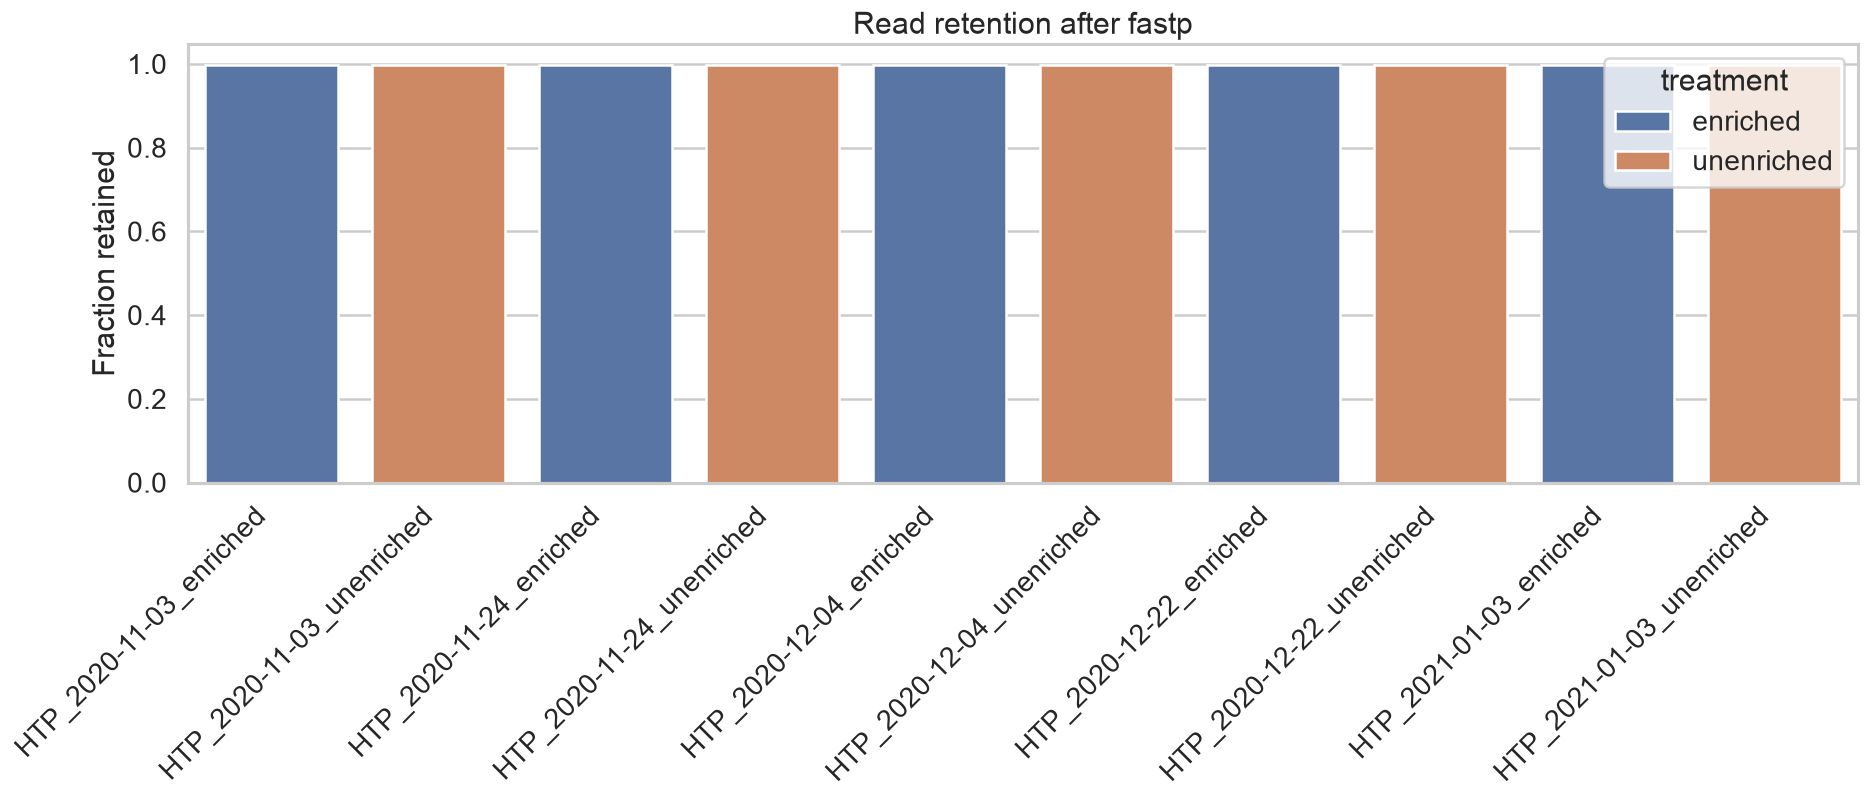

In [16]:
# Read Retention Plot
plt.figure(figsize=(16, 7))
sns.barplot(
    data=qc,
    x="sample",
    y="reads_retained_fraction",
    hue="treatment"
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Fraction retained")
plt.xlabel("")
plt.title("Read retention after fastp")
plt.tight_layout()
plt.show()

### Interpretation
> Across all dates and treatments, fastp retained essentially all paired-end reads (fraction retained ≈ 1.0), indicating that adapter and quality trimming removed very little data. Both enriched and unenriched libraries show similarly high retention, suggesting that neither treatment suffered from substantial adapter contamination or low-quality base content and that all samples are well suited for downstream host filtering and taxonomic analysis.

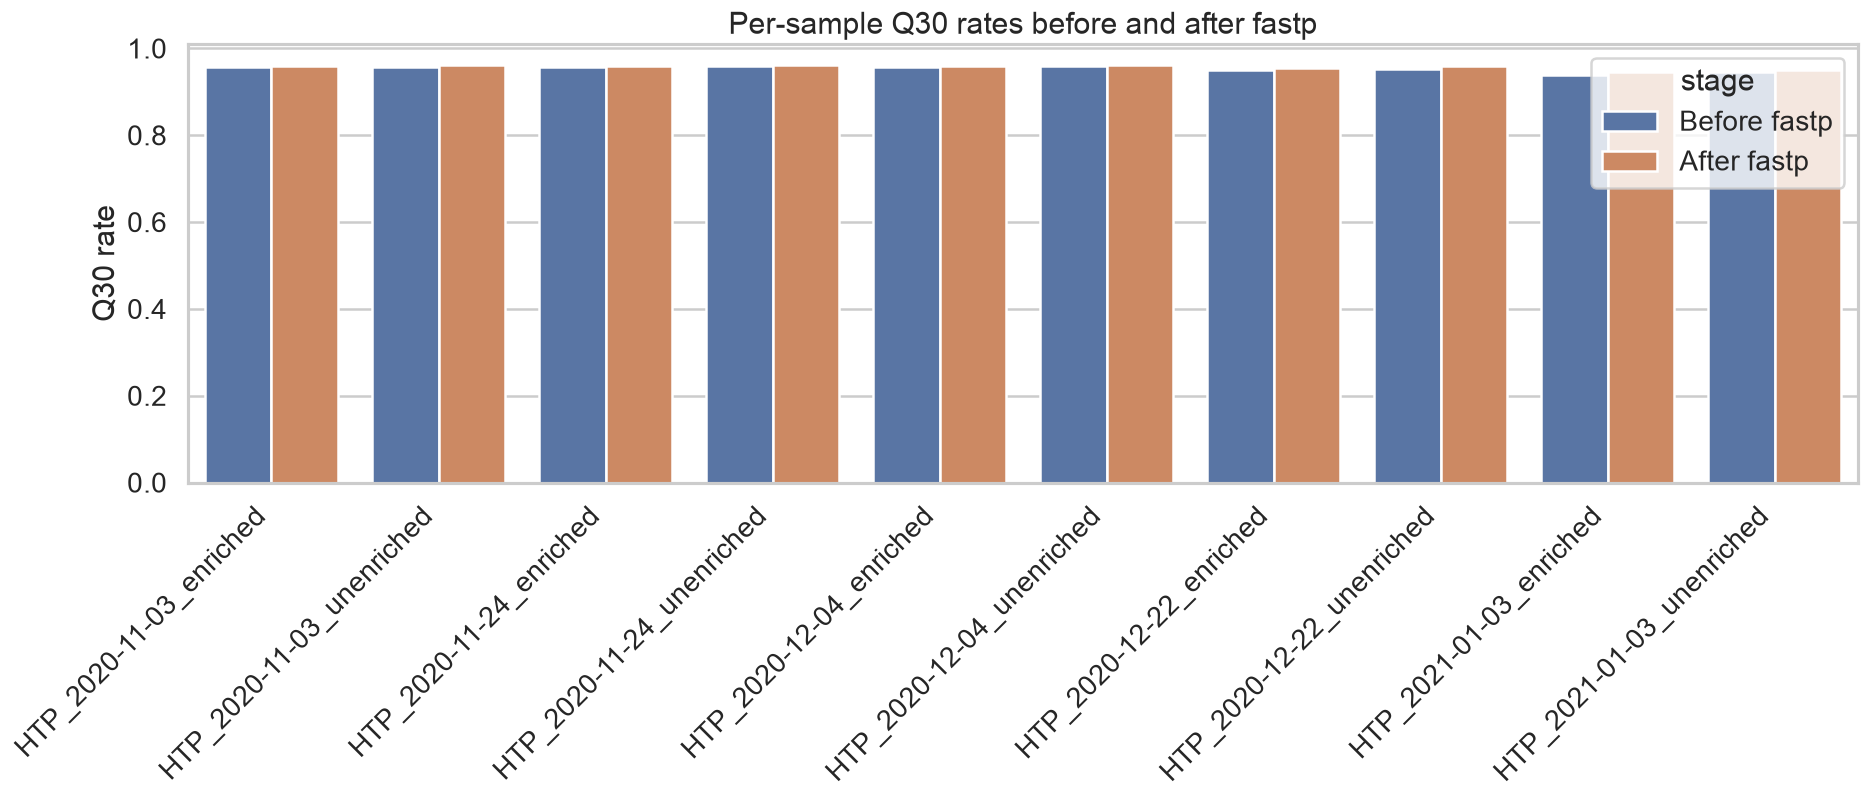

In [18]:
# Q30 before/after plot
qc_long = qc.melt(
    id_vars=["sample", "date", "treatment"],
    value_vars=["q30_rate_before", "q30_rate_after"],
    var_name="stage",
    value_name="q30_rate"
)

qc_long["stage"] = qc_long["stage"].map({
    "q30_rate_before": "Before fastp",
    "q30_rate_after": "After fastp"
})

plt.figure(figsize=(16, 7))
sns.barplot(
    data=qc_long,
    x="sample",
    y="q30_rate",
    hue="stage"
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Q30 rate")
plt.xlabel("")
plt.title("Per-sample Q30 rates before and after fastp")
plt.tight_layout()
plt.show()

### Interpretation
> Per-sample Q30 rates are uniformly high before trimming and remain high after fastp, indicating that the sequencing runs were already of good quality. fastp produces a slight improvement or stabilization of Q30 rates in both enriched and unenriched libraries, with no systematic quality differences between treatments, supporting the use of all samples for downstream analyses.

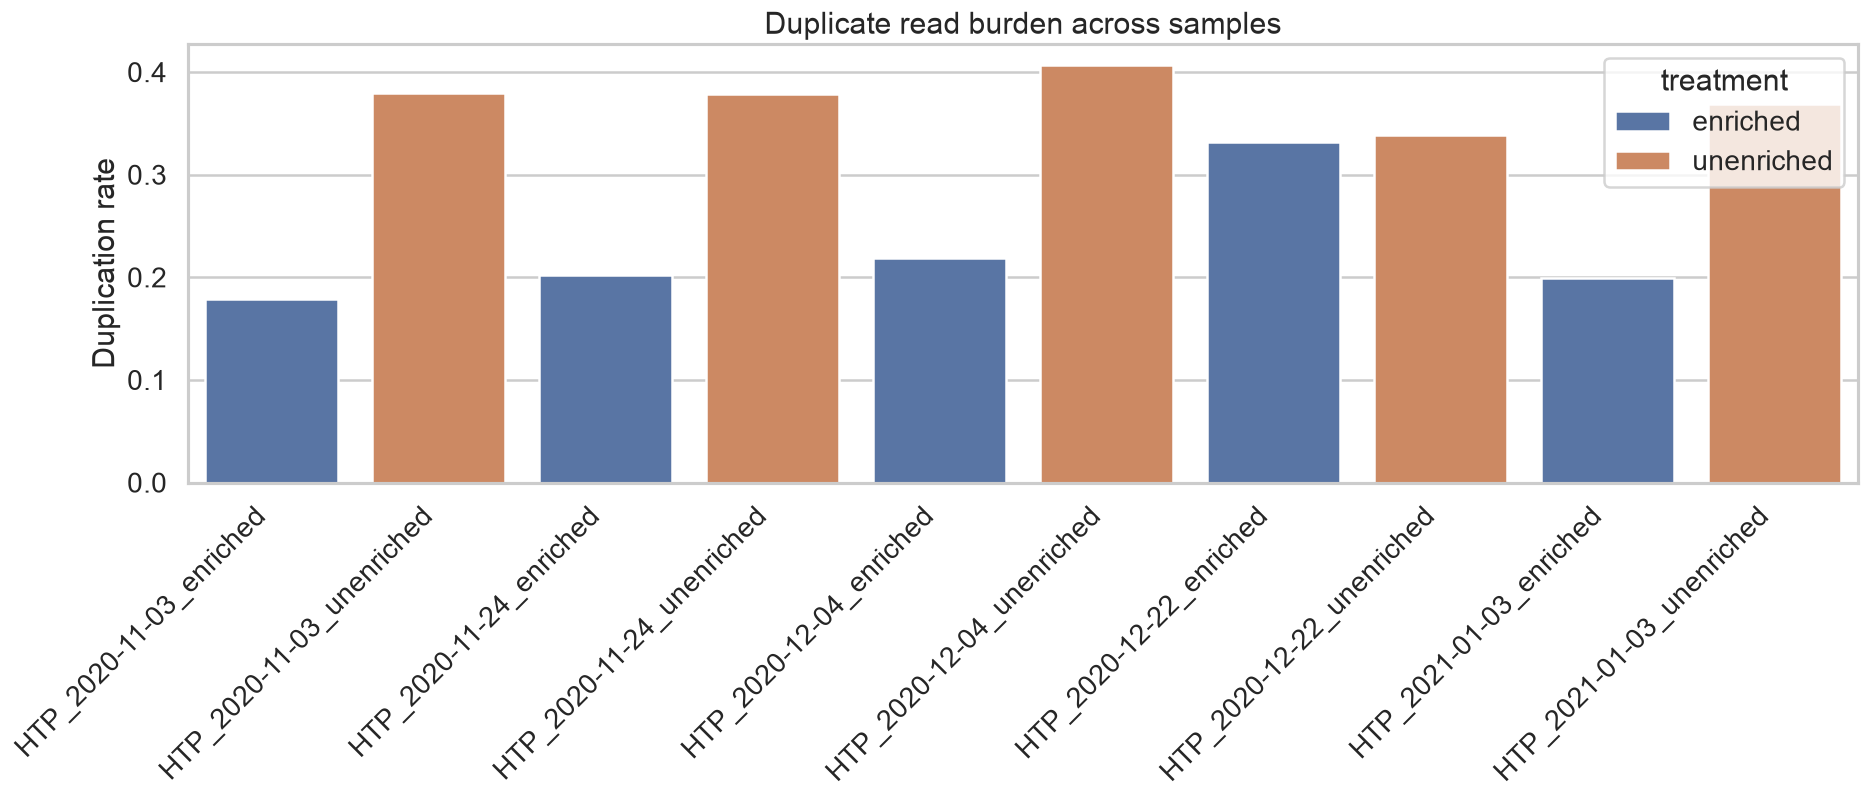

In [19]:
# Duplication rate plot
plt.figure(figsize=(16, 7))
sns.barplot(
    data=qc,
    x="sample",
    y="duplication_rate",
    hue="treatment"
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Duplication rate")
plt.xlabel("")
plt.title("Duplicate read burden across samples")
plt.tight_layout()
plt.show()

### Interpretation
> Duplicate read rates vary across samples, with unenriched libraries consistently showing higher duplication than their enriched counterparts. This pattern suggests that the unenriched preparations have more redundant sequencing of the same molecules, whereas the enriched libraries recover a larger fraction of unique fragments, which should improve effective complexity for downstream taxonomic and viral analyses.

### Quality Control (FASTP) MCQ

__Which conclusion is best supported if most reads are retained after fastp and Q30 values remain high across samples?__

> A) The sequencing data are suitable for downstream viromics analysis.  
> B) The samples should be discarded because trimming did not remove enough reads.  
> C) QC cannot affect taxonomic analysis.  
> D) Only enriched samples can be analyzed further.

### Deduplication MCQ

__You use `dedupe.sh` to remove exact duplicate paired-end reads before downstream analysis. Which conclusion is best supported if a substantial fraction of identical read pairs are removed across samples?__

> A) Many reads were technical duplicates, and deduplication helps reduce PCR/optical bias in downstream abundance estimates.  
> B) Deduplication is unnecessary because duplicate reads always reflect real biological replication.  
> C) Removing duplicate reads makes it impossible to estimate viral abundance.  
> D) Deduplication should only be run on single-end reads, not paired-end data.


## Host filtering

>Host filtering removes reads that map to the human reference genome (`GRCh38`, chromosome-level assembly), so downstream taxonomic analyses emphasize non-host biological signal. To do this, we align quality-controlled paired-end reads to the human genome using `bwa mem` and convert the alignments to BAM with `samtools view`, then extract only read pairs where both mates remain unmapped using `samtools` flag filters. This procedure yields host-filtered FASTQ files that are strongly depleted for human-derived sequences while retaining non-host RNA, allowing wastewater metatranscriptomic analyses to focus on microbial and viral composition rather than background human signal.

In [25]:
# Merge metadata into host summary
host = host.merge(
    meta[["sample", "date", "treatment", "site", "is_enriched"]],
    on="sample",
    how="left"
)
host = host.sort_values(["date", "treatment"])

display(host)

,sample,bam,total_reads,mapped_reads,unmapped_reads,both_mates_unmapped,mapped_fraction,unmapped_fraction,both_mates_unmapped_fraction,date,treatment,site,is_enriched
0,HTP_2020-11-03_enriched,results/host_filter/bwa/HTP_2020-11-03_enriche...,115592,39406,76186,76022,0.340906,0.659094,0.657675,2020-11-03,enriched,HTP,True
1,HTP_2020-11-03_unenriched,results/host_filter/bwa/HTP_2020-11-03_unenric...,114734,35020,79714,79572,0.305228,0.694772,0.693535,2020-11-03,unenriched,HTP,False
2,HTP_2020-11-24_enriched,results/host_filter/bwa/HTP_2020-11-24_enriche...,115580,40758,74822,74694,0.352639,0.647361,0.646254,2020-11-24,enriched,HTP,True
3,HTP_2020-11-24_unenriched,results/host_filter/bwa/HTP_2020-11-24_unenric...,115669,37749,77920,77796,0.326354,0.673646,0.672574,2020-11-24,unenriched,HTP,False
4,HTP_2020-12-04_enriched,results/host_filter/bwa/HTP_2020-12-04_enriche...,115049,40190,74859,74718,0.349329,0.650671,0.649445,2020-12-04,enriched,HTP,True
5,HTP_2020-12-04_unenriched,results/host_filter/bwa/HTP_2020-12-04_unenric...,116020,39361,76659,76554,0.339260,0.660740,0.659835,2020-12-04,unenriched,HTP,False
6,HTP_2020-12-22_enriched,results/host_filter/bwa/HTP_2020-12-22_enriche...,116918,42721,74197,73892,0.365393,0.634607,0.631998,2020-12-22,enriched,HTP,True
7,HTP_2020-12-22_unenriched,results/host_filter/bwa/HTP_2020-12-22_unenric...,119880,41058,78822,78638,0.342492,0.657508,0.655973,2020-12-22,unenriched,HTP,False
8,HTP_2021-01-03_enriched,results/host_filter/bwa/HTP_2021-01-03_enriche...,116338,39652,76686,76606,0.340834,0.659166,0.658478,2021-01-03,enriched,HTP,True
9,HTP_2021-01-03_unenriched,results/host_filter/bwa/HTP_2021-01-03_unenric...,116880,36514,80366,80284,0.312406,0.687594,0.686893,2021-01-03,unenriched,HTP,False


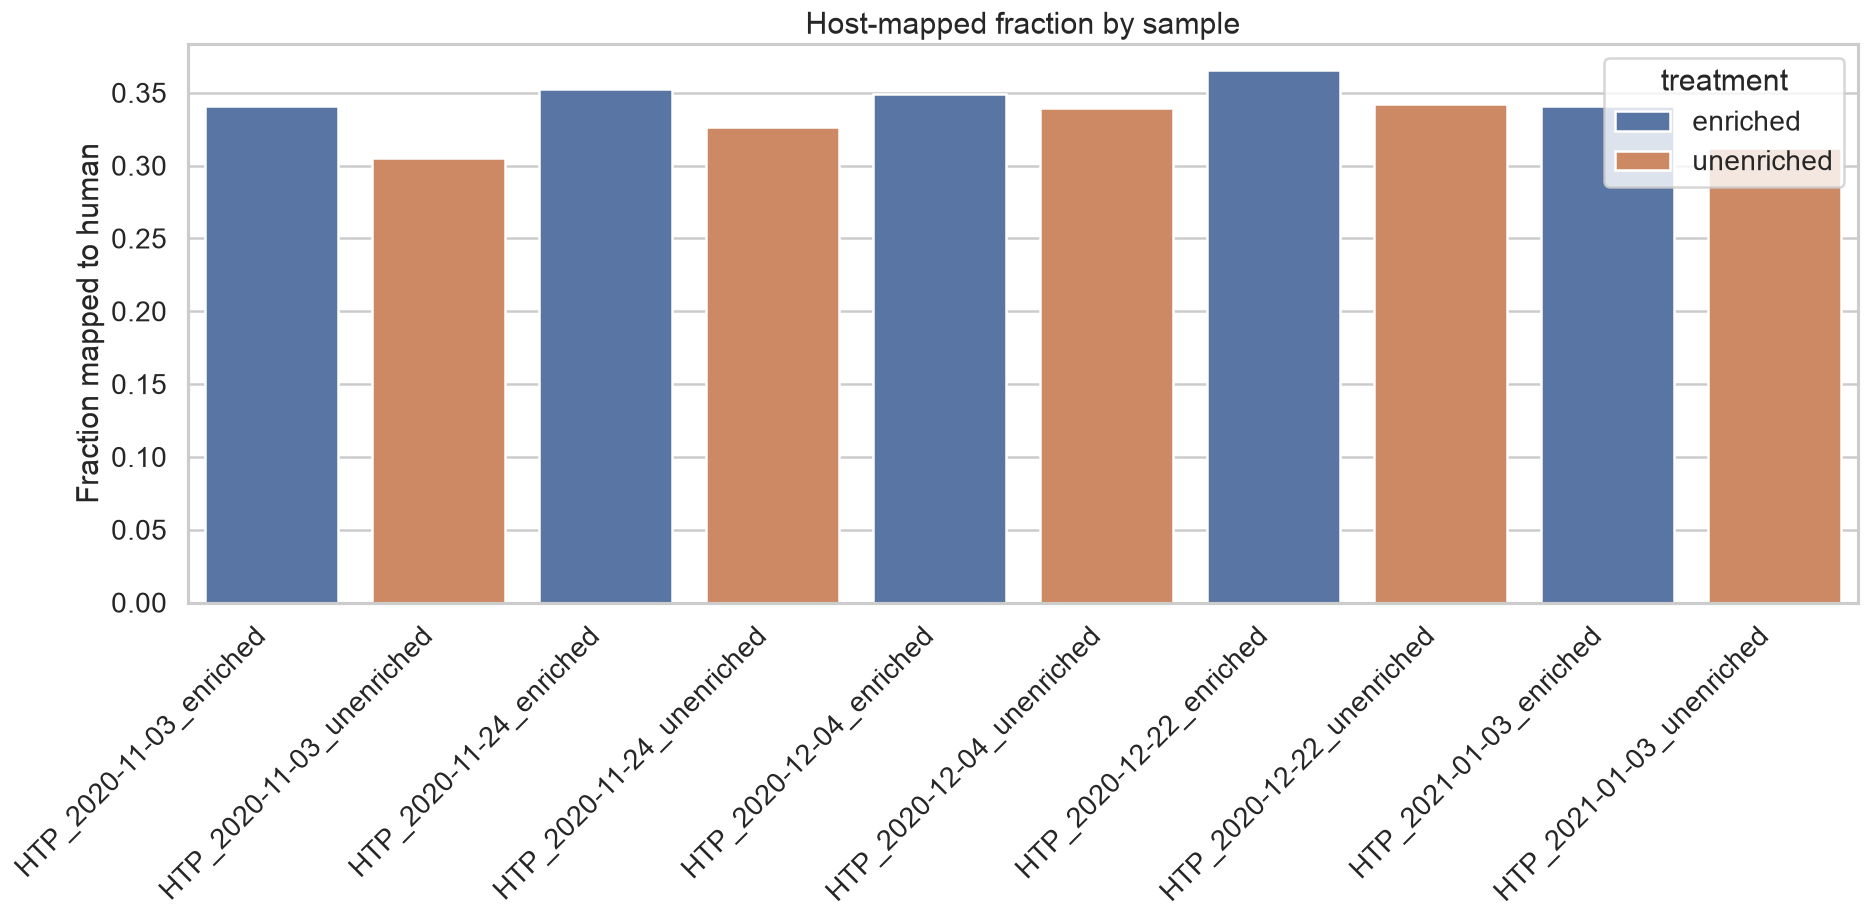

In [31]:
# Host-mapped fraction plot
plt.figure(figsize=(16, 8))
sns.barplot(
    data=host,
    x="sample",
    y="mapped_fraction",
    hue="treatment"
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Fraction mapped to human")
plt.xlabel("")
plt.title("Host-mapped fraction by sample")
plt.tight_layout()
plt.show()

### Interpretation

> Across all time points, roughly one third of reads map to the human genome, confirming that host RNA is a substantial component of these wastewater libraries. Within each date, enriched samples consistently show a slightly higher host-mapped fraction than the corresponding unenriched samples, indicating that the enrichment protocol amplifies both human and non-human RNA. This means downstream host-filtering will remove more reads from enriched libraries, but both treatments still retain ample non-host material for comparative viromics analyses.

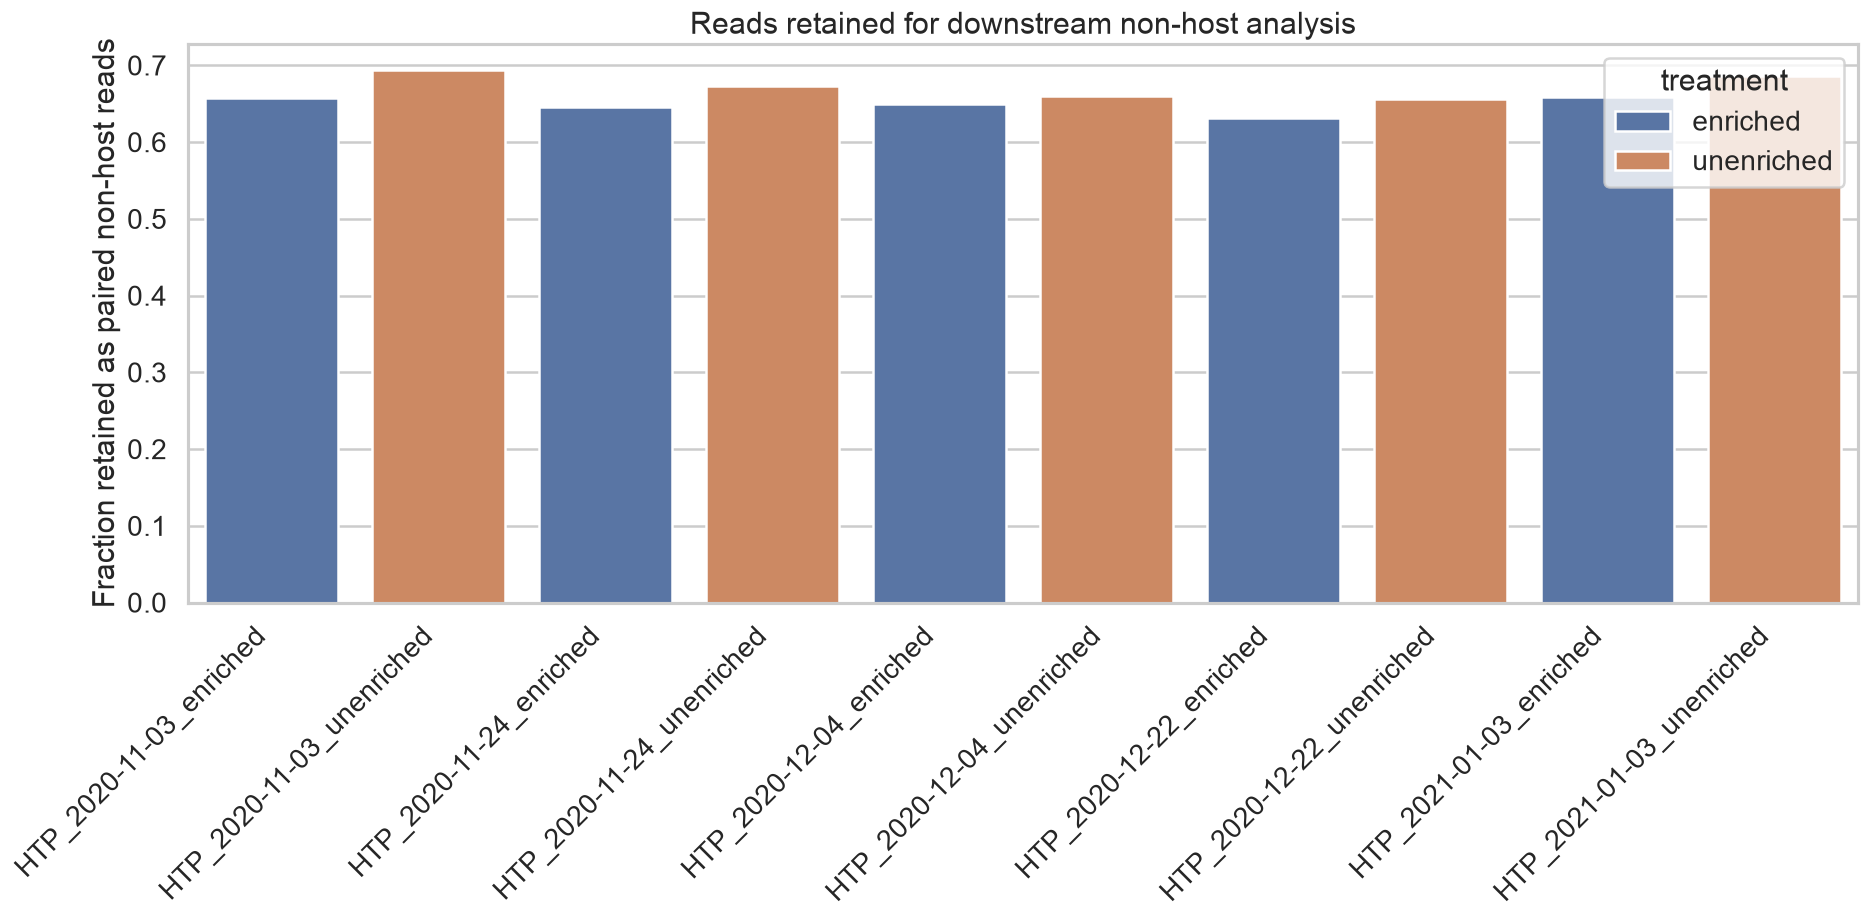

In [33]:
# Non-host retained fraction plot
plt.figure(figsize=(16, 8))
sns.barplot(
    data=host,
    x="sample",
    y="both_mates_unmapped_fraction",
    hue="treatment"
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Fraction retained as paired non-host reads")
plt.xlabel("")
plt.title("Reads retained for downstream non-host analysis")
plt.tight_layout()
plt.show()

### Interpretation
> Across all dates, roughly two thirds of read pairs are retained as non-host reads after human mapping and filtering, indicating that a substantial fraction of each library is available for downstream microbial and viral analyses. Enriched and unenriched samples show very similar retained fractions within each date, suggesting that although enrichment increases total sequencing depth and host content, both treatments ultimately contribute comparable amounts of non-host information once host reads are removed.

### Host filtering MCQ

__After aligning paired-end reads to the human reference genome and keeping only read pairs where both mates remain unmapped, which biological conclusion is best supported?__

> A) The retained read pairs are enriched for non-human (microbial and viral) sequences and are appropriate for wastewater viromics analysis.  
> B) All host-associated sequences have been removed, so no human reads can remain.  
> C) Host filtering is only useful for single-end data and should be avoided for paired-end reads.  
> D) Reads that map to the human genome are more informative for viral taxonomy and should be kept.

### Downsampling MCQ

__You downsample each host-filtered library to a fixed number of bases (e.g., ~10M bp) before taxonomic classification. Which conclusion is best supported about the effect of this step?__

> A) Downsampling standardizes sequencing depth across samples, making relative abundance and diversity comparisons more interpretable.  
> B) Downsampling always increases sensitivity for detecting rare viruses.  
> C) Downsampling is only needed when samples fail quality control.  
> D) Downsampling removes all high-quality reads and should be avoided.

## Taxonomic composition

> Broad taxonomic composition provides context for the non-host RNA background present in wastewater and helps interpret whether enrichment changes the observable community profile. Here, we classify host-filtered reads using `Kraken2` against a comprehensive database to assign reads across bacterial, archaeal, eukaryotic, and viral taxa, and then use `Bracken` to refine abundance estimates at selected taxonomic ranks. The resulting profiles summarize how enriched versus unenriched libraries sample the underlying community, and they contextualize the more detailed viral abundance analysis that follows by highlighting which major clades contribute most of the non-host signal in each treatment.

In [51]:
# Inspect merged bracken results table structure
print("Genus shape:", None if genus is None else genus.shape)
print("Species shape:", None if species is None else species.shape)

if genus is not None:
    display(genus.head())

if species is not None:
    display(species.head())

Genus shape: (248, 13)
Species shape: (245, 13)


,taxon,taxonomy_id,taxonomy_lvl,HTP_2020-11-03_enriched,HTP_2020-11-03_unenriched,HTP_2020-11-24_enriched,HTP_2020-11-24_unenriched,HTP_2020-12-04_enriched,HTP_2020-12-04_unenriched,HTP_2020-12-22_enriched,HTP_2020-12-22_unenriched,HTP_2021-01-03_enriched,HTP_2021-01-03_unenriched
0,Pseudomonas,286,G,1345.0,1034.0,1074.0,1062.0,2027.0,1517.0,947.0,1215.0,470.0,511.0
1,Salmonella,590,G,2964.0,2742.0,1652.0,2427.0,1638.0,1454.0,2141.0,2811.0,1563.0,2143.0
2,Klebsiella,570,G,163.0,273.0,337.0,157.0,169.0,259.0,384.0,354.0,199.0,246.0
3,Enterobacter,547,G,314.0,232.0,262.0,269.0,182.0,180.0,204.0,445.0,299.0,337.0
4,Escherichia,561,G,143.0,185.0,96.0,264.0,115.0,379.0,163.0,172.0,141.0,112.0


,taxon,taxonomy_id,taxonomy_lvl,HTP_2020-11-03_enriched,HTP_2020-11-03_unenriched,HTP_2020-11-24_enriched,HTP_2020-11-24_unenriched,HTP_2020-12-04_enriched,HTP_2020-12-04_unenriched,HTP_2020-12-22_enriched,HTP_2020-12-22_unenriched,HTP_2021-01-03_enriched,HTP_2021-01-03_unenriched
0,Pseudomonas marginalis,298,S,60.0,70.0,32.0,43.0,19.0,53.0,88.0,63.0,66.0,100.0
1,Pseudomonas fluorescens,294,S,16.0,23.0,0.0,12.0,0.0,0.0,0.0,12.0,0.0,31.0
2,Pseudomonas aeruginosa,287,S,1197.0,805.0,984.0,847.0,1747.0,1169.0,725.0,561.0,301.0,292.0
3,Pseudomonas syringae,317,S,13.0,13.0,13.0,0.0,0.0,21.0,0.0,0.0,0.0,0.0
4,Salmonella enterica,28901,S,3628.0,3560.0,2536.0,2667.0,1927.0,1730.0,3133.0,3438.0,1996.0,2457.0


In [52]:
# Helper to id sample columns
sample_order = meta.sort_values(["date", "treatment"])["sample"].tolist()
sample_set = set(sample_order)

def get_sample_columns(df, sample_names):
    return [c for c in df.columns if c in sample_names]

genus_sample_cols = get_sample_columns(genus, sample_set) if genus is not None else []
species_sample_cols = get_sample_columns(species, sample_set) if species is not None else []

print("Genus sample columns:", genus_sample_cols[:5], "...", len(genus_sample_cols))
print("Species sample columns:", species_sample_cols[:5], "...", len(species_sample_cols))

Genus sample columns: ['HTP_2020-11-03_enriched', 'HTP_2020-11-03_unenriched', 'HTP_2020-11-24_enriched', 'HTP_2020-11-24_unenriched', 'HTP_2020-12-04_enriched'] ... 10
Species sample columns: ['HTP_2020-11-03_enriched', 'HTP_2020-11-03_unenriched', 'HTP_2020-11-24_enriched', 'HTP_2020-11-24_unenriched', 'HTP_2020-12-04_enriched'] ... 10


In [53]:
# choose taxon name column
def guess_taxon_col(df):
    candidates = ["name", "taxon_name", "taxonomy", "genus", "species"]
    for c in candidates:
        if c in df.columns:
            return c
    return df.columns[0]

genus_taxon_col = guess_taxon_col(genus) if genus is not None else None
species_taxon_col = guess_taxon_col(species) if species is not None else None

print("Genus taxon column:", genus_taxon_col)
print("Species taxon column:", species_taxon_col)

Genus taxon column: taxon
Species taxon column: taxon


In [54]:
# convert to relative abundance
def make_relative_abundance(df, taxon_col, sample_cols):
    out = df[[taxon_col] + sample_cols].copy()
    out = out.groupby(taxon_col, as_index=False)[sample_cols].sum()
    col_sums = out[sample_cols].sum(axis=0)
    out[sample_cols] = out[sample_cols].div(col_sums.replace(0, np.nan), axis=1).fillna(0)
    return out

genus_rel = make_relative_abundance(genus, genus_taxon_col, genus_sample_cols) if genus is not None else None
species_rel = make_relative_abundance(species, species_taxon_col, species_sample_cols) if species is not None else None

if genus_rel is not None:
    display(genus_rel.head())

if species_rel is not None:
    display(species_rel.head())

,taxon,HTP_2020-11-03_enriched,HTP_2020-11-03_unenriched,HTP_2020-11-24_enriched,HTP_2020-11-24_unenriched,HTP_2020-12-04_enriched,HTP_2020-12-04_unenriched,HTP_2020-12-22_enriched,HTP_2020-12-22_unenriched,HTP_2021-01-03_enriched,HTP_2021-01-03_unenriched
0,Acetoanaerobium,0.000810,0.000834,0.00000,0.001066,0.000764,0.000985,0.001015,0.001092,0.000727,0.000710
1,Acetobacteroides,0.002254,0.002121,0.00218,0.002171,0.002438,0.003130,0.006249,0.004115,0.001928,0.002625
2,Achromobacter,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000619,0.000000,0.000000
3,Acidihalobacter,0.000000,0.000487,0.00000,0.000553,0.000000,0.000000,0.000508,0.000437,0.000000,0.000532
4,Acidovorax,0.001796,0.007787,0.00560,0.005959,0.011026,0.011287,0.012067,0.015220,0.019096,0.026396


,taxon,HTP_2020-11-03_enriched,HTP_2020-11-03_unenriched,HTP_2020-11-24_enriched,HTP_2020-11-24_unenriched,HTP_2020-12-04_enriched,HTP_2020-12-04_unenriched,HTP_2020-12-22_enriched,HTP_2020-12-22_unenriched,HTP_2021-01-03_enriched,HTP_2021-01-03_unenriched
0,Acidihalobacter ferrooxydans,0.0,0.000493,0.0,0.000558,0.000000,0.000000,0.000552,0.000439,0.000000,0.000000
1,Acidovorax carolinensis,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.003213
2,Acidovorax temperans,0.0,0.009018,0.0,0.006443,0.012564,0.013583,0.014214,0.017428,0.022121,0.025819
3,Acinetobacter baumannii,0.0,0.003410,0.0,0.000000,0.000000,0.004605,0.000000,0.006341,0.000000,0.003677
4,Adlercreutzia equolifaciens,0.0,0.001288,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [56]:
# top taxa selection
def top_taxa_table(rel_df, taxon_col, sample_cols, top_n=40):
    ranked = rel_df.assign(total_abundance=rel_df[sample_cols].sum(axis=1))
    ranked = ranked.sort_values("total_abundance", ascending=False).head(top_n)
    return ranked[[taxon_col] + sample_cols]

genus_top = top_taxa_table(genus_rel, genus_taxon_col, genus_sample_cols, top_n=40) if genus_rel is not None else None
species_top = top_taxa_table(species_rel, species_taxon_col, species_sample_cols, top_n=40) if species_rel is not None else None

In [57]:
# reorder columns by time / treatment
ordered_genus_cols = [s for s in sample_order if s in genus_sample_cols]
ordered_species_cols = [s for s in sample_order if s in species_sample_cols]

if genus_top is not None:
    genus_top = genus_top[[genus_taxon_col] + ordered_genus_cols]

if species_top is not None:
    species_top = species_top[[species_taxon_col] + ordered_species_cols]

### Heatmaps

> Heat maps provide a compact way to visualize the broad taxonomic profiles derived from `Kraken2` across all samples. By encoding relative abundance as color intensity and arranging taxa and samples in a matrix, heat maps make it easy to spot dominant clades, rare groups, and coordinated shifts between enriched and unenriched libraries that would be hard to see in raw tables or single-sample bar plots.

In [62]:
# Heatmap helper
def plot_taxonomy_heatmap(
    df,
    title,
    cmap="mako",
    log_transform=True,
    pseudocount=1e-6,
    show_every=1,
    min_height=8,
    row_height=0.28,
    y_fontsize=7,
    x_fontsize=9
):
    plot_df = df.copy()

    if log_transform:
        plot_df = np.log10(plot_df + pseudocount)

    n_rows = plot_df.shape[0]
    fig_height = max(min_height, n_rows * row_height)

    fig, ax = plt.subplots(figsize=(14, fig_height))
    sns.heatmap(
        plot_df,
        cmap=cmap,
        ax=ax,
        yticklabels=True,
        xticklabels=True,
        cbar_kws={
            "label": "log10(relative abundance)" if log_transform else "relative abundance"
        }
    )

    ax.set_title(title)
    ax.set_xlabel("Sample")
    ax.set_ylabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=x_fontsize)

    ylabels = plot_df.index.tolist()
    ypositions = np.arange(len(ylabels)) + 0.5

    if show_every > 1:
        ypositions = ypositions[::show_every]
        ylabels = ylabels[::show_every]

    ax.set_yticks(ypositions)
    ax.set_yticklabels(ylabels, rotation=0, fontsize=y_fontsize, va="center")

    plt.tight_layout()
    plt.show()

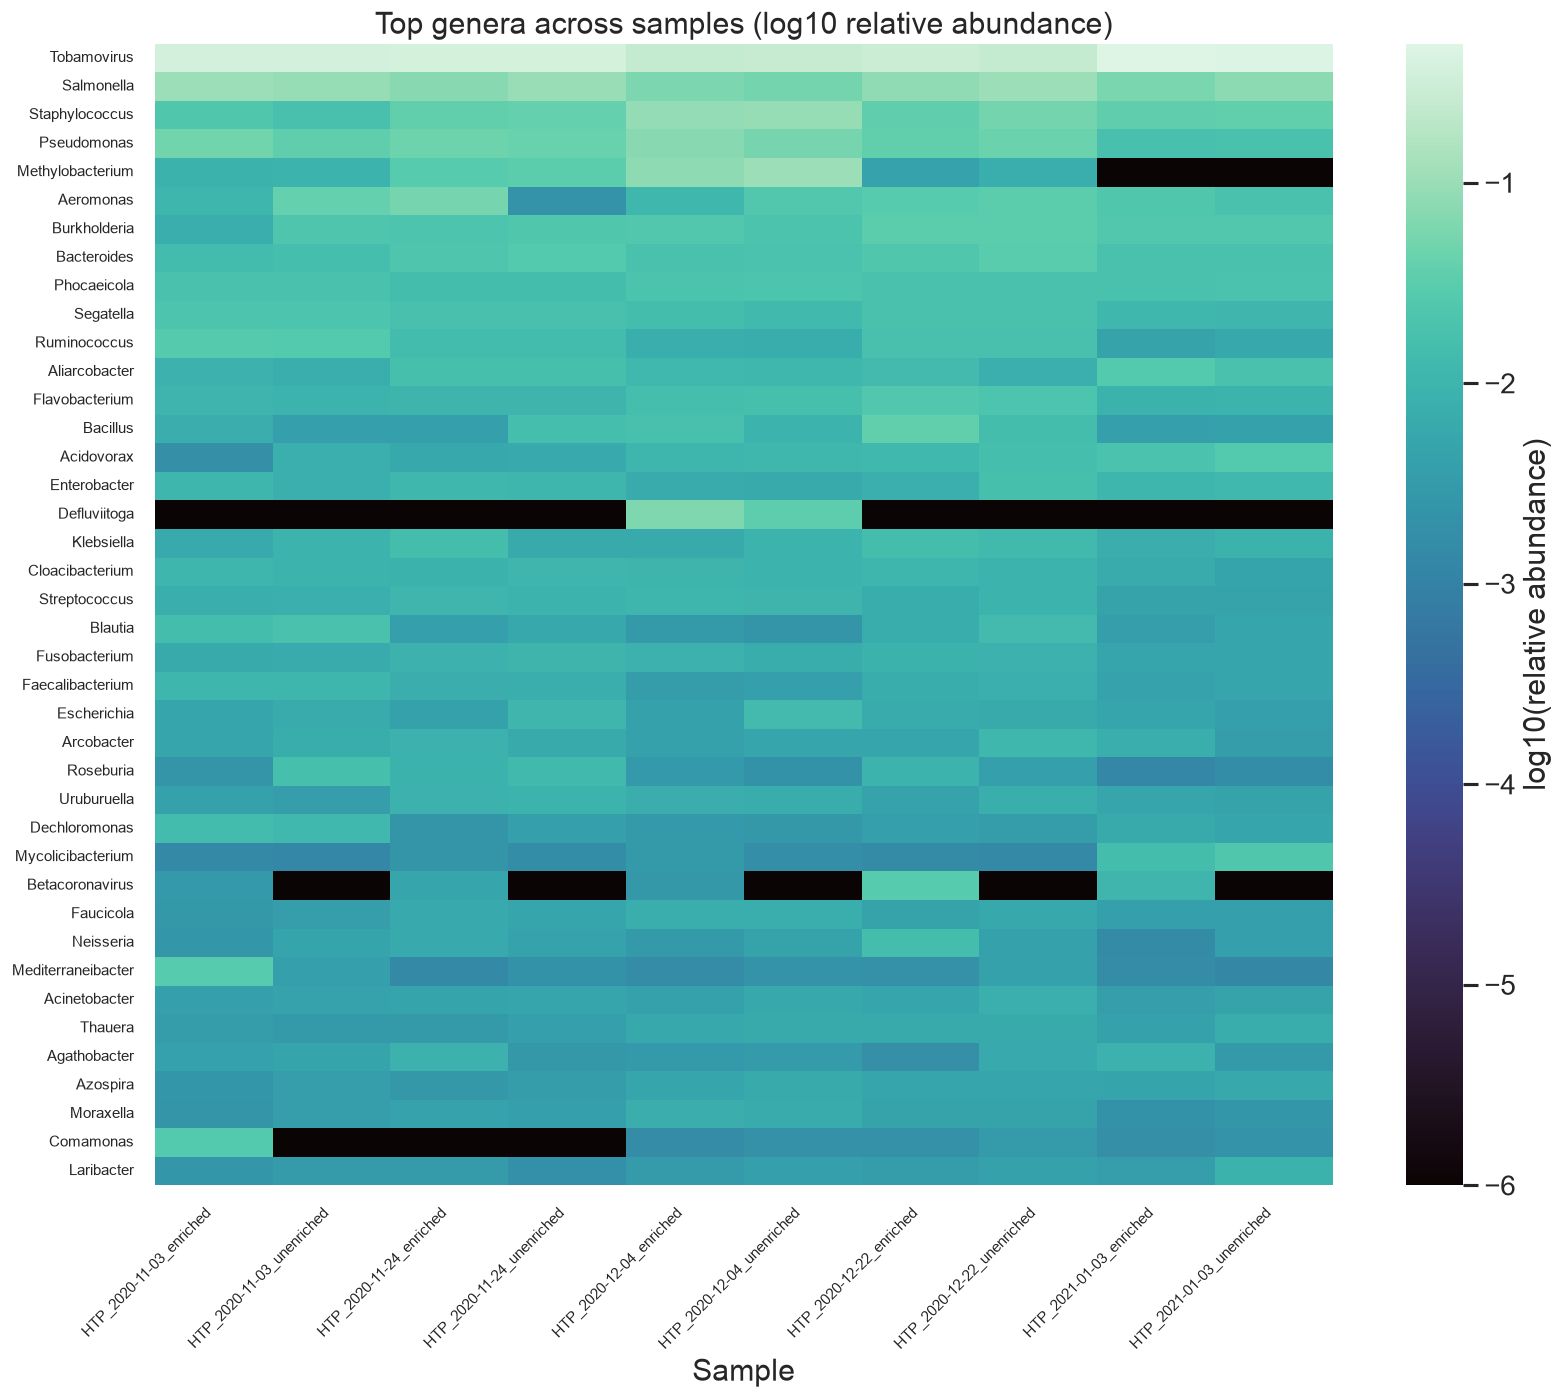

In [67]:
# Genus Heatmap
if genus_top is not None:
    genus_heat = genus_top.set_index(genus_taxon_col)

    plot_taxonomy_heatmap(
        genus_heat,
        title="Top genera across samples (log10 relative abundance)",
        cmap="mako",
        log_transform=True,
        pseudocount=1e-6,
        show_every=1,
        min_height=8,
        row_height=0.30,
        y_fontsize=9,
        x_fontsize=9
    )

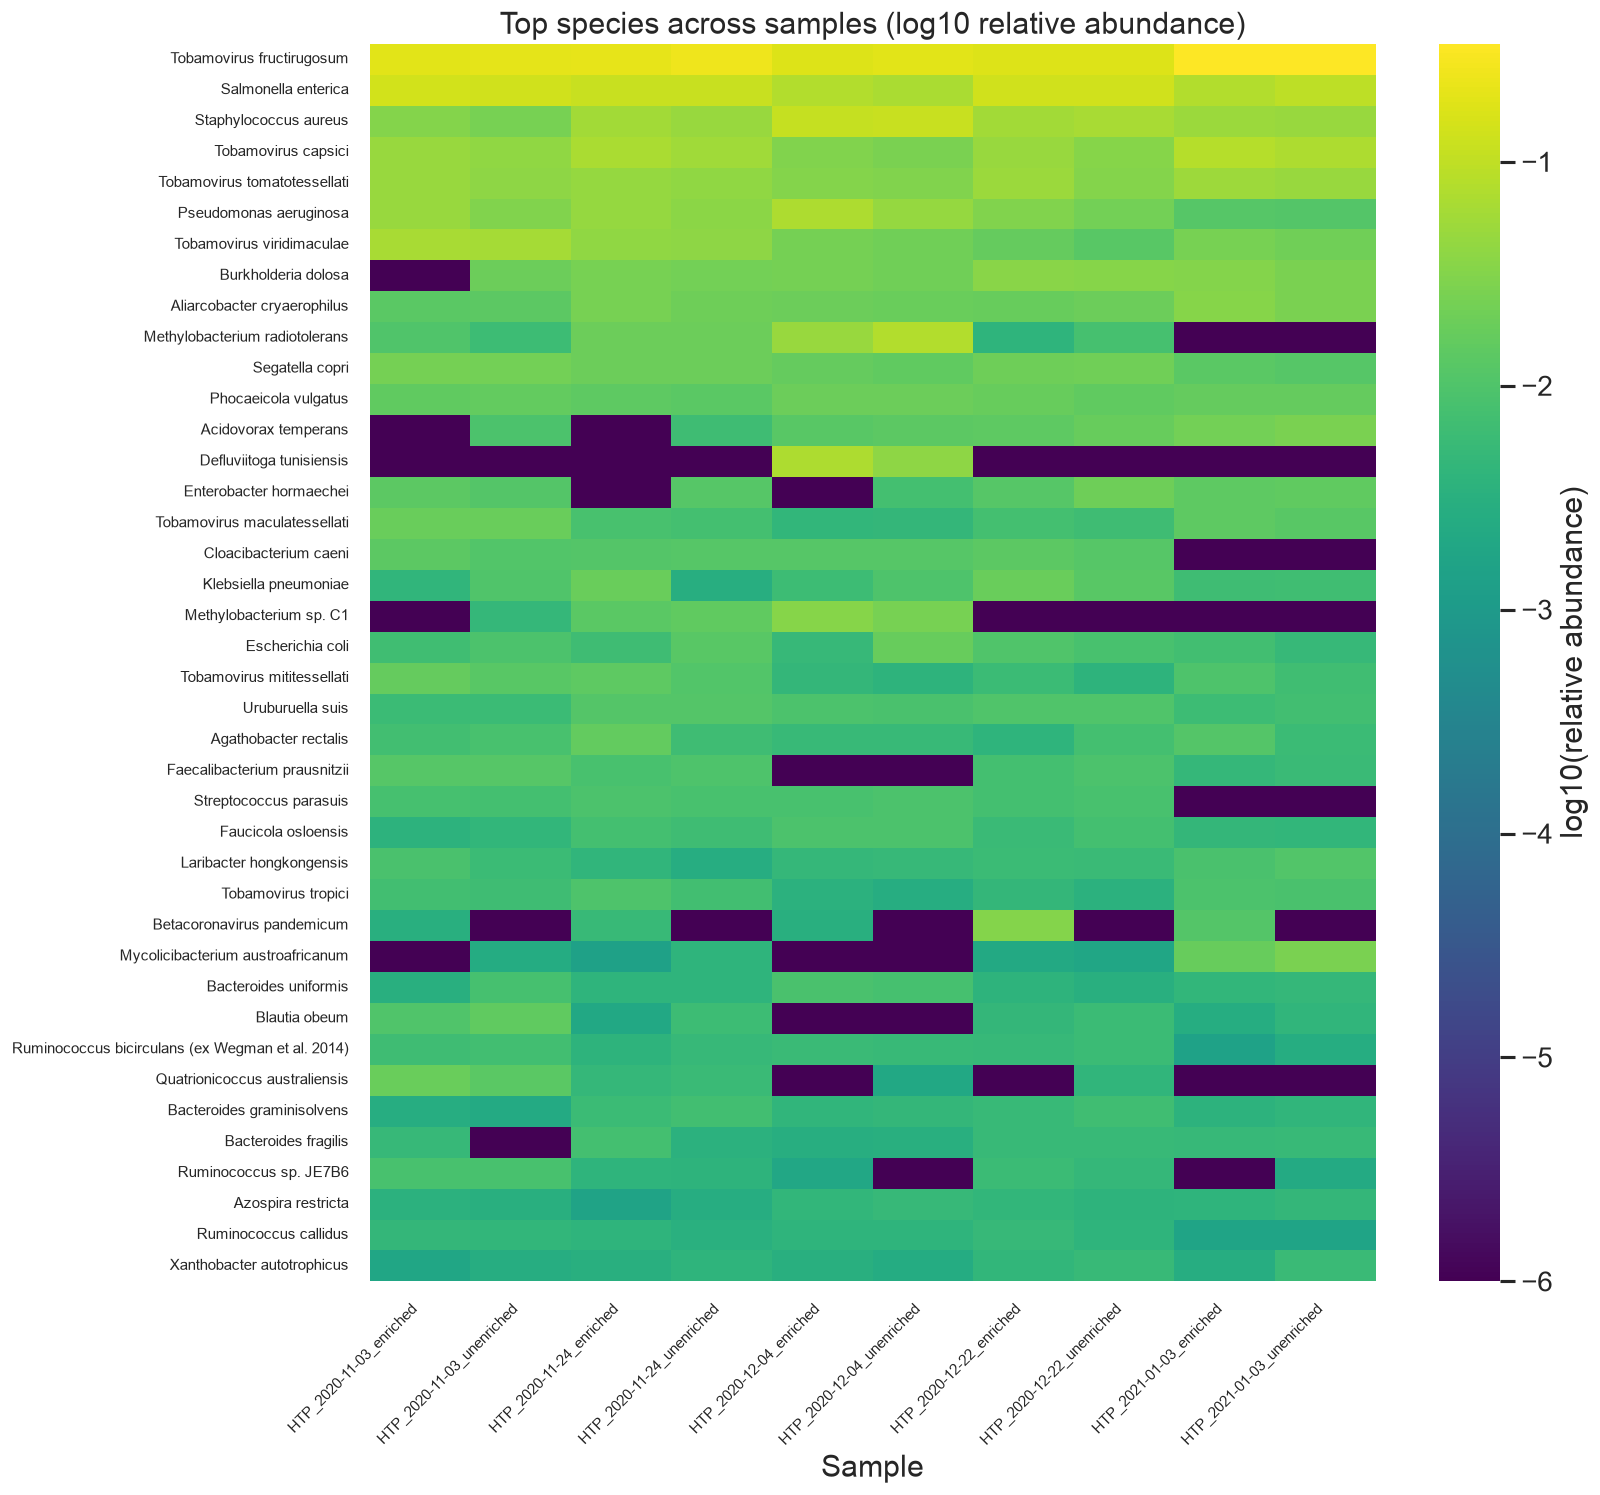

In [68]:
# Species heatmap
# Species Heatmap
if species_top is not None:
    species_heat = species_top.set_index(species_taxon_col)

    plot_taxonomy_heatmap(
        species_heat,
        title="Top species across samples (log10 relative abundance)",
        cmap="viridis",
        log_transform=True,
        pseudocount=1e-6,
        show_every=1,   # change to 2 if labels are still crowded
        min_height=8,
        row_height=0.32,
        y_fontsize=9,
        x_fontsize=9
    )

> Heatmaps were plotted using log10-transformed relative abundances because the taxonomic abundance distributions were highly skewed. This transformation reduced dominance by the most abundant taxa and improved visibility of temporal structure among moderately and low-abundance taxa. A small pseudocount was added before transformation so taxa with zero abundance in individual samples could still be included in the visualization.

> Broad taxonomic heatmaps were used to summarize how the wastewater community profile changed across time and treatment conditions. Heatmaps were preferred over stacked bar plots because they preserve visibility of many taxa simultaneously, including moderately and low-abundance taxa that would be difficult to interpret in highly compositional bar charts.
>
> The genus- and species-level heatmaps show that the wastewater metatranscriptomic background is taxonomically broad and varies across collection dates. Comparing matched enriched and unenriched samples helps distinguish temporal shifts in community composition from treatment-associated shifts in recoverable taxa.

### Clustered Heatmaps
> In addition to simple heat maps, clustered heat maps of the merged `Bracken` tables help reveal structure in the taxonomic profiles across samples. By hierarchically clustering and reordering the columns (samples) based on similarity in their relative abundance vectors, samples with more similar community compositions are placed next to each other, making coherent groups and outliers visually obvious. This reordering highlights whether enriched libraries tend to cluster together or intermingle with unenriched libraries, and it can reveal date- or treatment-specific patterns in the wastewater community that are much harder to detect from unclustered tables or bar plots.

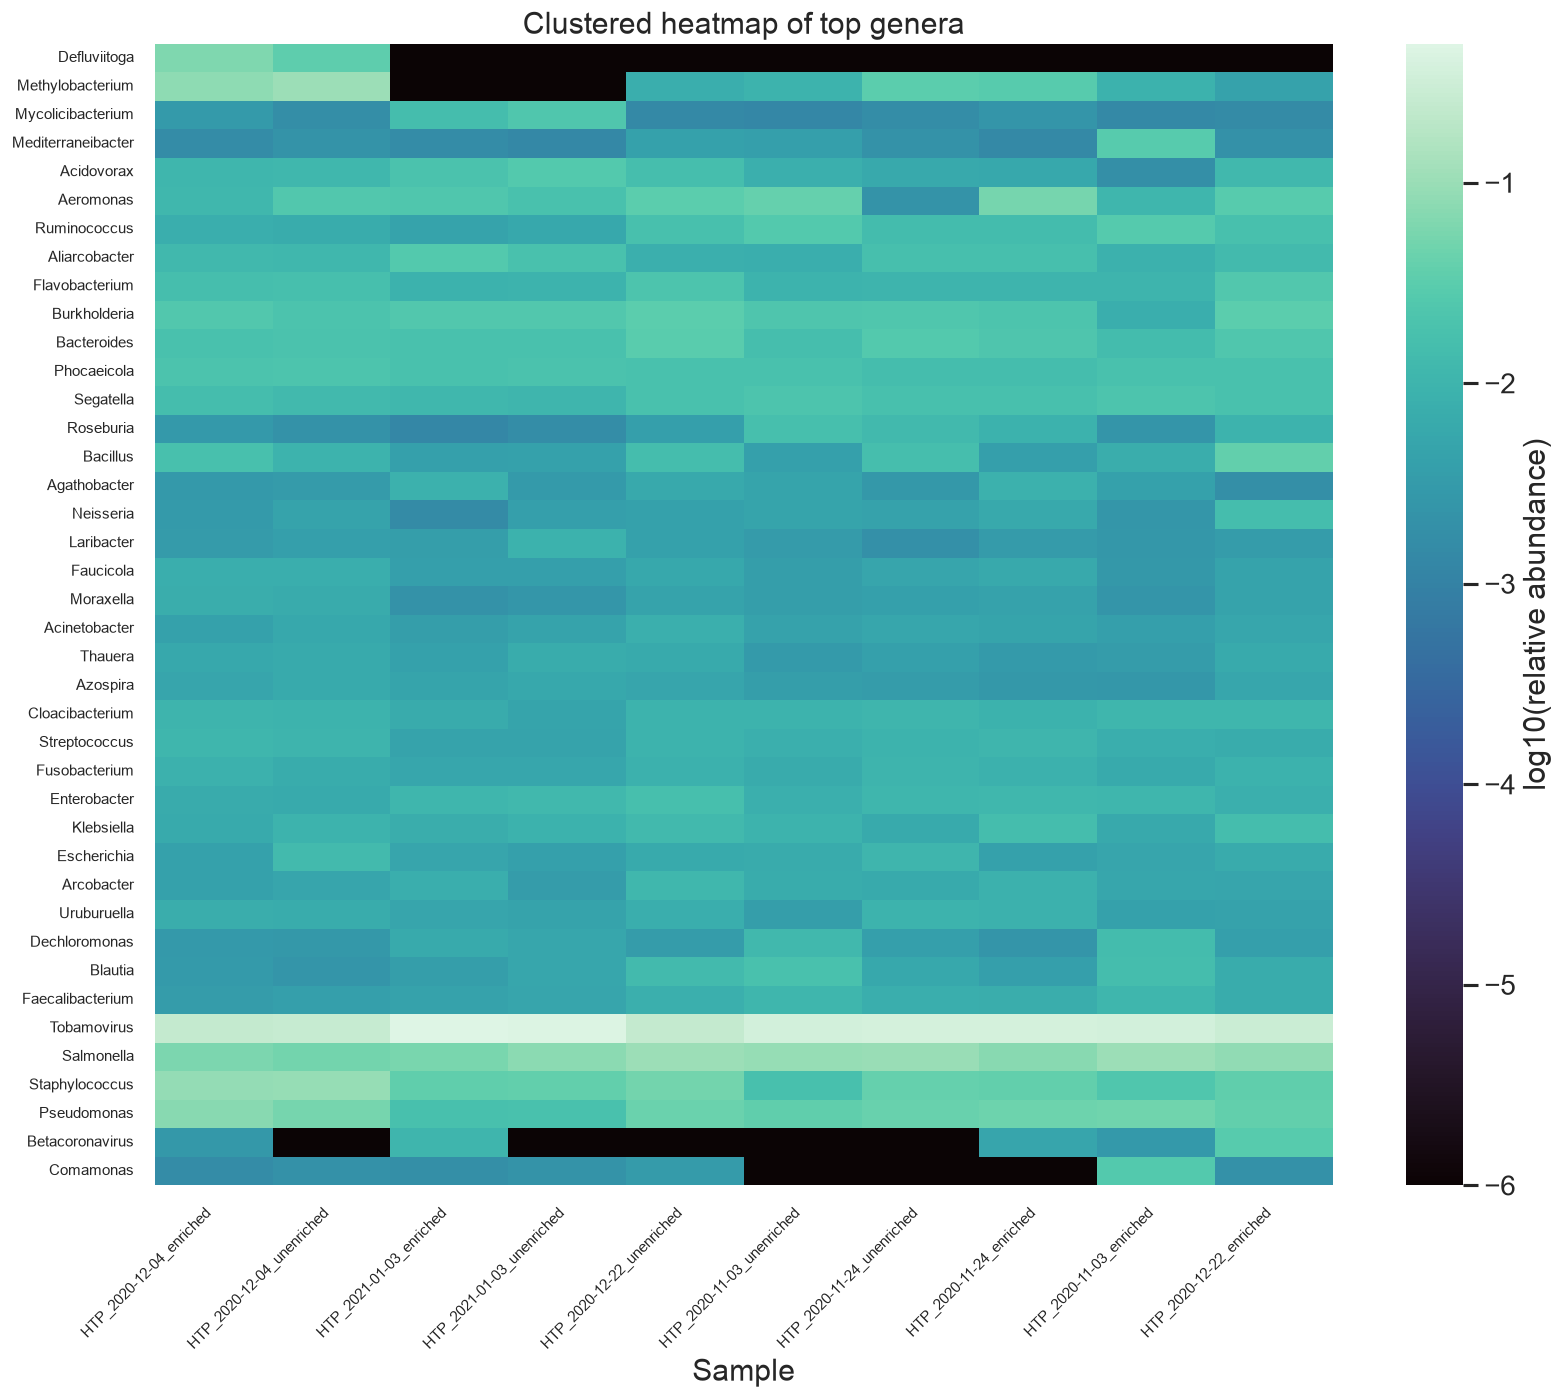

In [99]:
# genus clustered heatmap
if genus_top is not None:
    genus_cluster = genus_top.set_index(genus_taxon_col).copy()
    genus_cluster_log = np.log10(genus_cluster + 1e-6)

    row_linkage = linkage(pdist(genus_cluster_log.values, metric="euclidean"), method="average")
    col_linkage = linkage(pdist(genus_cluster_log.T.values, metric="euclidean"), method="average")

    row_order = leaves_list(row_linkage)
    col_order = leaves_list(col_linkage)

    genus_clustered = genus_cluster.iloc[row_order, col_order]

    plot_taxonomy_heatmap(
        genus_clustered,
        title="Clustered heatmap of top genera",
        cmap="mako",
        log_transform=True,
        pseudocount=1e-6,
        show_every=1,
        min_height=8,
        row_height=0.30,
        y_fontsize=9,
        x_fontsize=9
    )

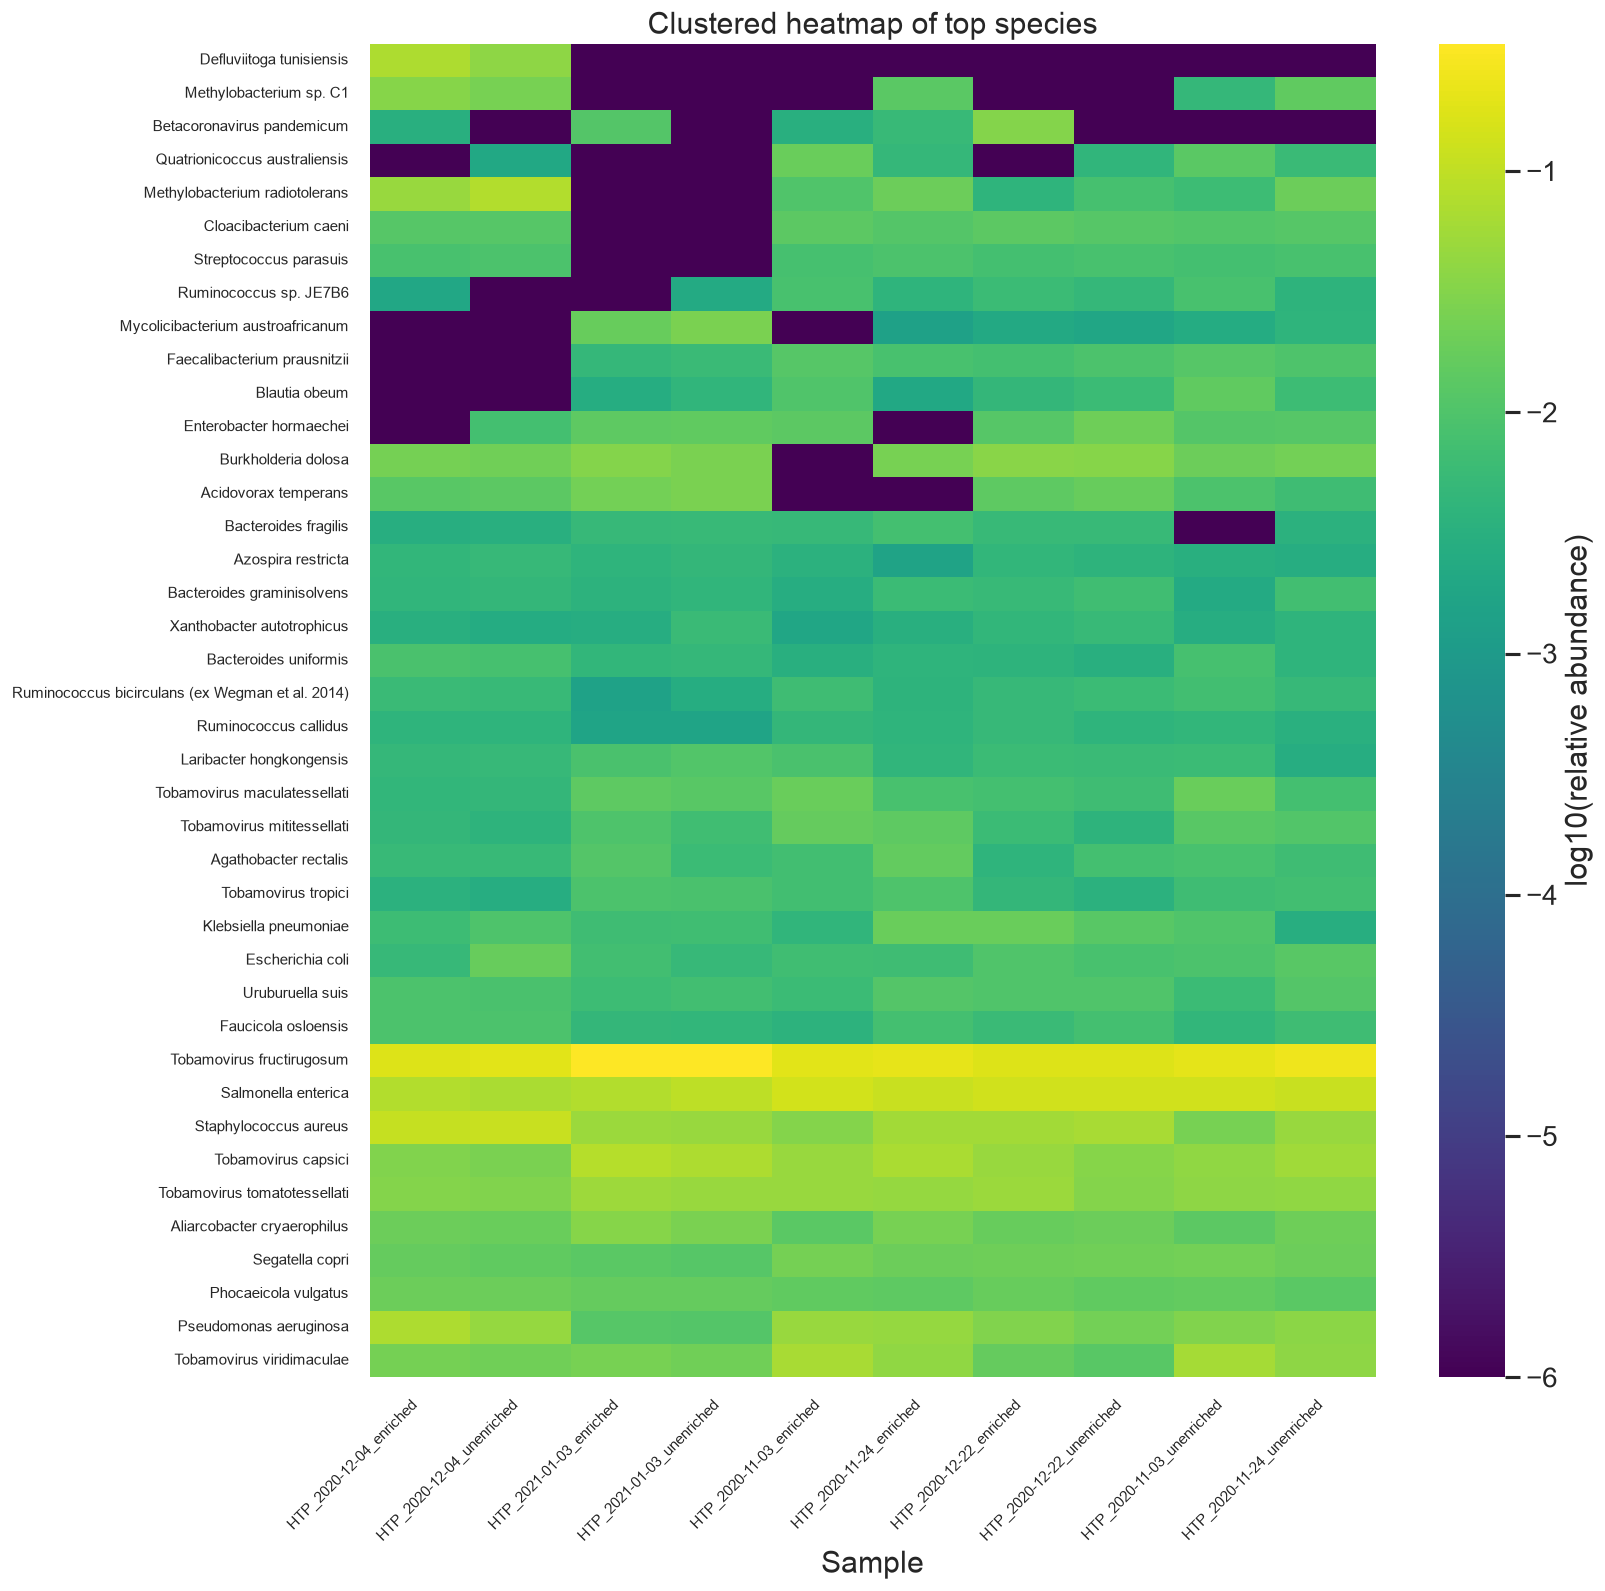

In [100]:
# Species clustered heatmap
from scipy.cluster.hierarchy import linkage, leaves_list

from scipy.spatial.distance import pdist

if species_top is not None:
    species_cluster = species_top.set_index(species_taxon_col).copy()
    species_cluster_log = np.log10(species_cluster + 1e-6)

    row_linkage = linkage(pdist(species_cluster_log.values, metric="euclidean"), method="average")
    col_linkage = linkage(pdist(species_cluster_log.T.values, metric="euclidean"), method="average")

    row_order = leaves_list(row_linkage)
    col_order = leaves_list(col_linkage)

    species_clustered = species_cluster.iloc[row_order, col_order]

    plot_taxonomy_heatmap(
        species_clustered,
        title="Clustered heatmap of top species",
        cmap="viridis",
        log_transform=True,
        pseudocount=1e-6,
        show_every=1,     # or 2 if needed
        min_height=8,
        row_height=0.34,
        y_fontsize=9,
        x_fontsize=9
    )

### Interpretation

> To improve interpretability, clustered heatmaps were generated using the same top taxa shown in the standard ordered heatmaps. Restricting clustering to the most abundant taxa preserved comparability between figures while avoiding visually overloaded dendrograms dominated by very low-abundance taxa.
> 
> Species profiles were hierarchically clustered and then replotted as an ordered heatmap rather than using the default clustered heatmap rendering directly. This preserved the clustering-derived ordering while allowing explicit control of row-label placement and readability for dense species-level taxonomic data.
> 
> The clustered heat map shows that many dominant bacterial and viral species are shared across all samples, and most variation occurs at relatively modest levels. After clustering, enriched and unenriched libraries do not form clearly separated blocks, and there is no obvious ordering by time point, suggesting that broad species-level community structure is largely stable across both treatments and dates in this small subset of samples.

### Broad taxonomic profiling MCQ

__You use `Kraken2` followed by `Bracken` on host-filtered reads to generate species-level relative abundance profiles for enriched and unenriched wastewater libraries. The dominant taxa include common human-associated gut bacteria and several RNA viruses across all samples, and enriched and unenriched libraries show broadly similar community structure. Which conclusion is best supported by these results?__

> A) Enrichment fundamentally reshapes the overall microbial community, so enriched and unenriched samples cannot be compared at the community level.  
> B) Broad non-host community composition is relatively stable across treatments and time points, so enrichment mainly changes sequencing depth rather than which major taxa are detected.  
> C) The presence of human-associated bacteria proves that host-filtering failed and all reads are still human.  
> D) Kraken2/Bracken profiles are unreliable for wastewater and should be discarded in favor of de novo assembly only.

## Viral relative abundance

> Species-level viral relative abundance is the core analysis in this notebook because the main biological question concerns how wastewater viral composition changes across time and between enriched and unenriched libraries. Using `Kraken2` followed by `Bracken` on host-filtered reads, we derive species-level viral relative abundance profiles that quantify how much of each library is represented by individual RNA viruses. This section focuses on dominant viral taxa in these `Kraken2`/`Bracken` profiles and asks how enrichment reshapes the observed virome compared to unenriched libraries at matched time points.

In [36]:
# Clean viral table
viral["date"] = pd.to_datetime(viral["date"])
viral = viral.sort_values(["date", "treatment", "reads"], ascending=[True, True, False])

display(viral.head(20))

,sample,site,date,treatment,taxonomy_lvl,taxonomy_id,name,reads,viral_total_reads,relative_abundance,is_viral,is_sars_cov_2
0,HTP_2020-11-03_enriched,HTP,2020-11-03,enriched,S,3432872,Tobamovirus fructirugosum,4742.0,10136.0,0.467837,True,False
1,HTP_2020-11-03_enriched,HTP,2020-11-03,enriched,S,3432895,Tobamovirus viridimaculae,1585.0,10136.0,0.156373,True,False
2,HTP_2020-11-03_enriched,HTP,2020-11-03,enriched,S,3432892,Tobamovirus tomatotessellati,1227.0,10136.0,0.121054,True,False
3,HTP_2020-11-03_enriched,HTP,2020-11-03,enriched,S,3432865,Tobamovirus capsici,1215.0,10136.0,0.119870,True,False
4,HTP_2020-11-03_enriched,HTP,2020-11-03,enriched,S,3432877,Tobamovirus maculatessellati,462.0,10136.0,0.045580,True,False
5,HTP_2020-11-03_enriched,HTP,2020-11-03,enriched,S,3432879,Tobamovirus mititessellati,416.0,10136.0,0.041042,True,False
6,HTP_2020-11-03_enriched,HTP,2020-11-03,enriched,S,3432893,Tobamovirus tropici,178.0,10136.0,0.017561,True,False
7,HTP_2020-11-03_enriched,HTP,2020-11-03,enriched,S,3418604,Betacoronavirus pandemicum,80.0,10136.0,0.007893,True,True
8,HTP_2020-11-03_enriched,HTP,2020-11-03,enriched,S,1923145,Hubei picorna-like virus 62,66.0,10136.0,0.006511,True,False
9,HTP_2020-11-03_enriched,HTP,2020-11-03,enriched,S,1923146,Hubei picorna-like virus 63,50.0,10136.0,0.004933,True,False


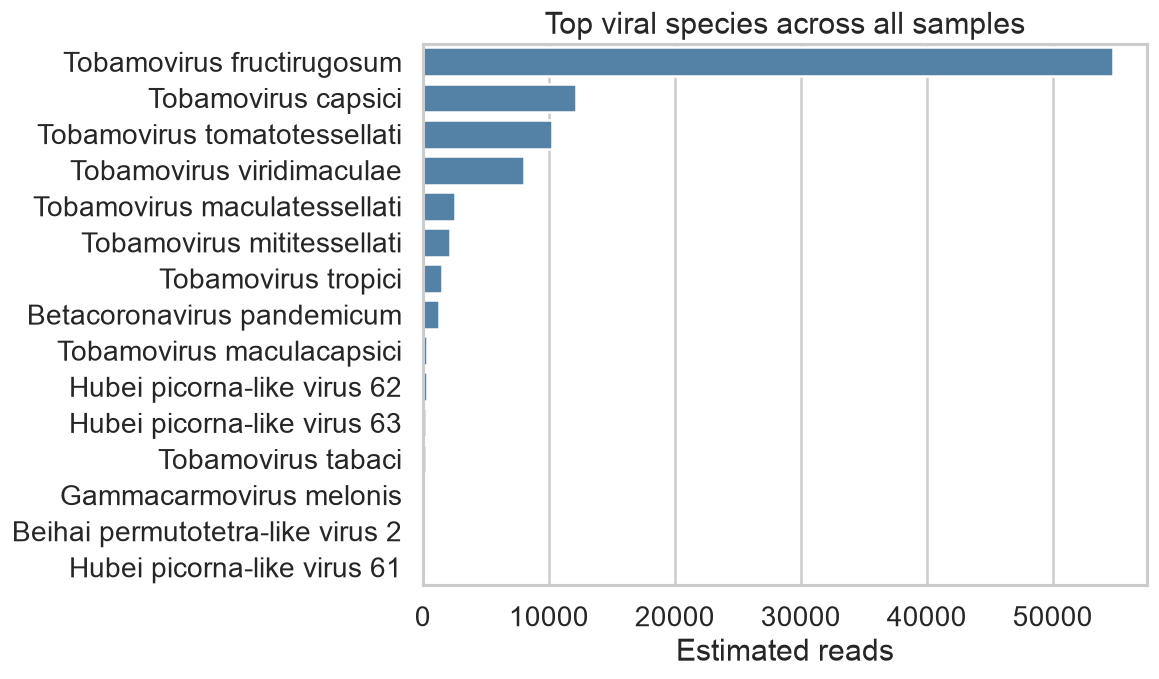

In [37]:
# Top viral taxa overall
overall_top = (
    viral.groupby("name", as_index=False)["reads"]
    .sum()
    .sort_values("reads", ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=overall_top,
    y="name",
    x="reads",
    color="steelblue"
)
plt.title("Top viral species across all samples")
plt.xlabel("Estimated reads")
plt.ylabel("")
plt.tight_layout()
plt.show()

### Interpretation

> This bar plot shows that the wastewater virome is dominated by plant-associated tobamoviruses, with *Tobamovirus fructirugosum* contributing the largest share of viral reads. Other tobamoviruses and a small number of additional RNA viruses are present at much lower abundances, indicating a highly skewed viral community where a few taxa account for most of the detected viral signal.

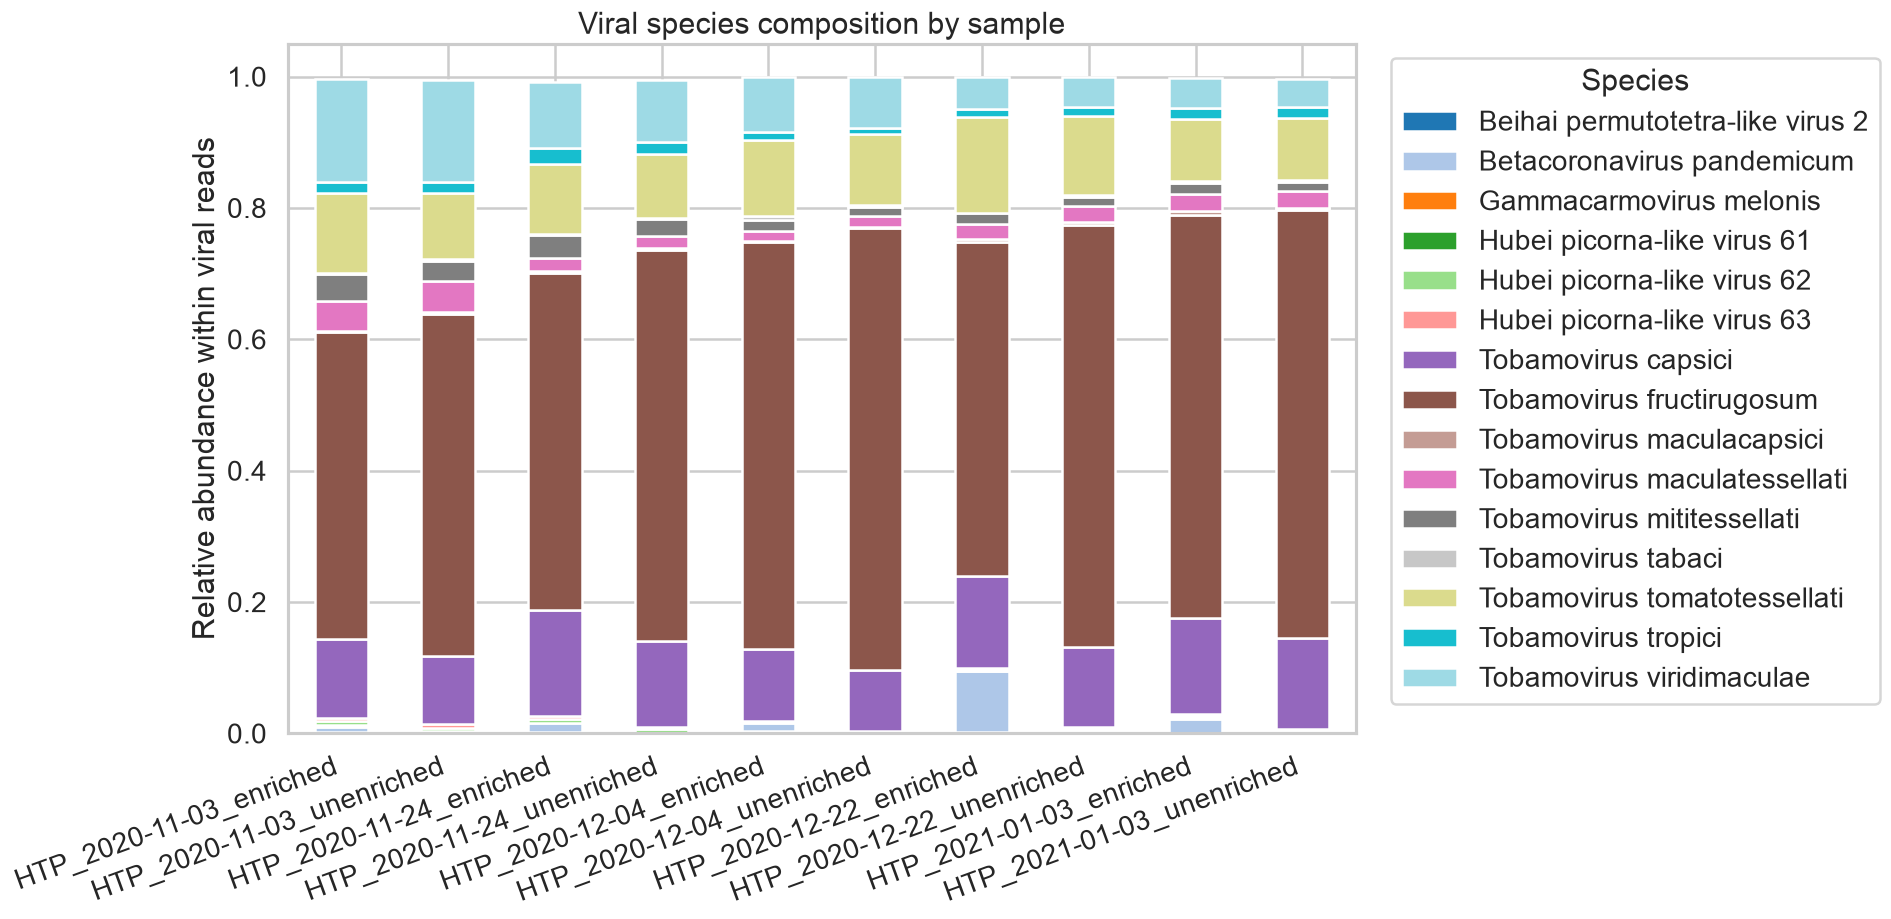

In [41]:
# Stacked composition by sample
top_taxa = overall_top["name"].tolist()

viral_top = viral[viral["name"].isin(top_taxa)].copy()

pivot_top = viral_top.pivot_table(
    index="sample",
    columns="name",
    values="relative_abundance",
    aggfunc="sum",
    fill_value=0
)

sample_order = meta.sort_values(["date", "treatment"])["sample"].tolist()
pivot_top = pivot_top.reindex(sample_order)

pivot_top.plot(
    kind="bar",
    stacked=True,
    figsize=(16, 8),
    colormap="tab20"
)
plt.ylabel("Relative abundance within viral reads")
plt.xlabel("")
plt.title("Viral species composition by sample")
plt.xticks(rotation=20, ha="right")
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    title="Species"
)
plt.tight_layout()
plt.show()

### Interpretation
> These stacked bar plots illustrate that the wastewater virome is consistently dominated by a few tobamoviruses, with smaller contributions from other plant and picorna-like viruses, but the exact proportions of individual species are hard to read because many colors are stacked in a narrow bar. Despite this limitation, enriched and unenriched samples at each time point look broadly similar in composition, and the overall viral mixture remains stable across dates, with no obvious time point where a new viral species becomes dominant or disappears.

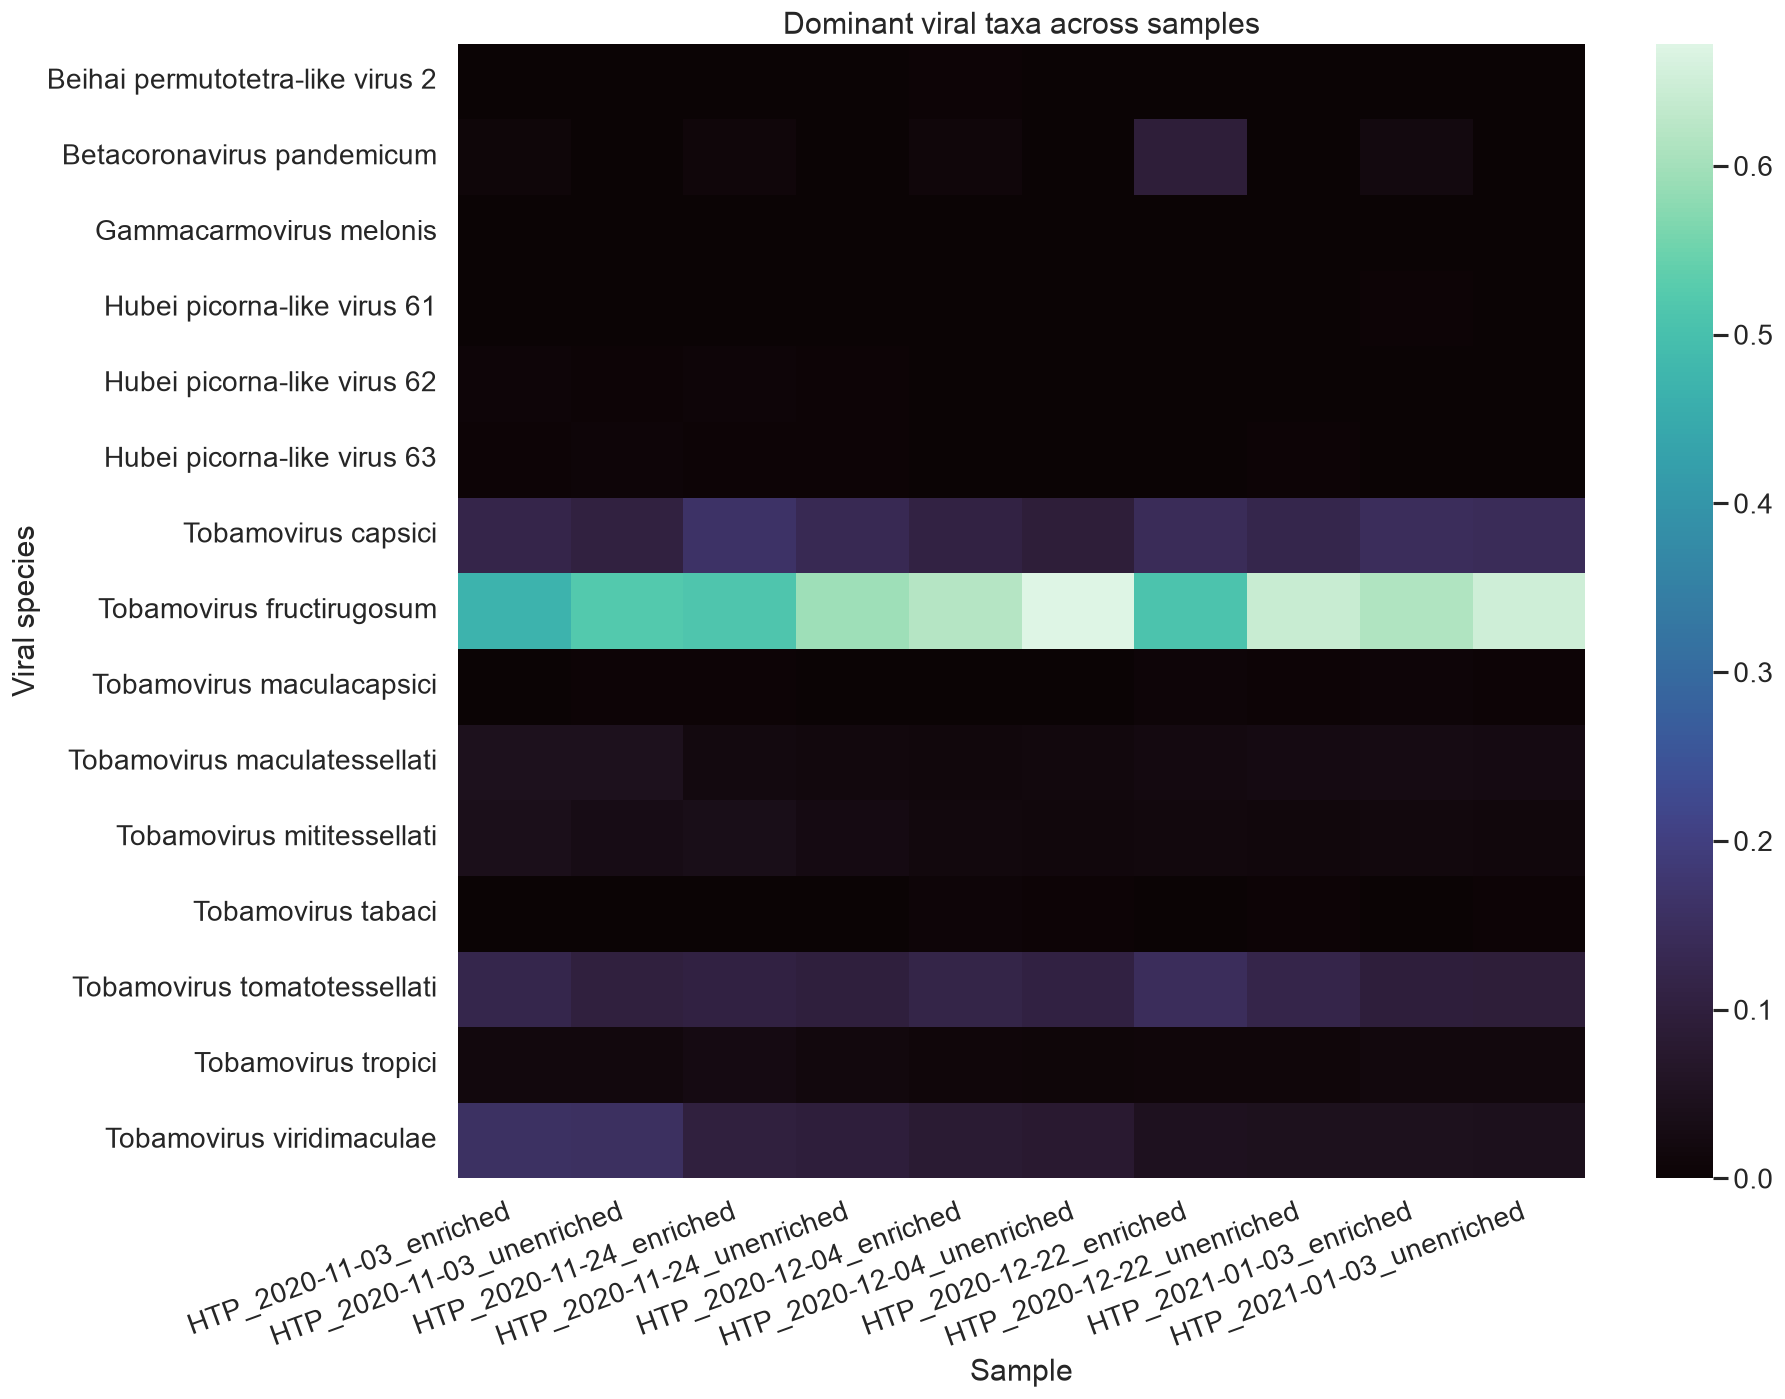

In [43]:
# Viral Heatmap
heat = viral_top.pivot_table(
    index="name",
    columns="sample",
    values="relative_abundance",
    aggfunc="sum",
    fill_value=0
)

plt.figure(figsize=(16, 12))
sns.heatmap(heat, cmap="mako")
plt.title("Dominant viral taxa across samples")
plt.xlabel("Sample")
plt.xticks(rotation=20, ha="right")
plt.ylabel("Viral species")
plt.tight_layout()
plt.show()

### Interpretation

> This heat map highlights that *Tobamovirus fructirugosum* dominates the virome in every sample, with *Tobamovirus capsici* and a few other tobamoviruses contributing smaller but consistent fractions. Enriched and unenriched libraries at each time point show very similar relative abundance patterns for these dominant viruses, and there is no clear temporal shift in which viral species are most abundant, suggesting a stable tobamovirus-dominated wastewater virome over the sampled interval.

### Viral taxa profiling MCQ

__You use `Kraken2`/`Bracken` on host-filtered reads to quantify species-level viral relative abundances across enriched and unenriched wastewater libraries. The results show that a handful of tobamoviruses, especially *Tobamovirus fructirugosum*, dominate all samples, while other plant and picorna-like viruses contribute much smaller fractions, and enriched and unenriched samples at each time point have very similar viral compositions. Which conclusion is best supported by these observations?__

> A) Enrichment dramatically changes which viral species are detected, leading to entirely different viromes in enriched versus unenriched libraries.  
> B) The wastewater virome is consistently dominated by a stable set of tobamoviruses, and enrichment primarily increases viral sequencing depth without strongly reshaping the relative composition of the dominant viral taxa.  
> C) The presence of plant viruses indicates that all viral reads are contamination and the wastewater samples contain no genuine viral signal.  
> D) Because stacked bar plots and heat maps are difficult to interpret, no biological conclusions about viral composition can be drawn from the `Kraken2`/`Bracken` results.

## SARS-CoV-2 abundance and SNVs

> Because the original study explicitly targeted SARS-CoV-2 detection and wastewater SNV profiling, this section begins by attempting to pull out SARS-CoV-2-specific signal from the broader `Kraken2`/`Bracken` viral results, followed by attempts to dig deeper by carrying out read-level alignments. Here we first examine SARS-CoV-2 abundance across enriched and unenriched libraries to assess whether there is sufficient coverage for robust genome-wide analysis. When coverage and depth are adequate, these summaries motivate downstream alignment-based SNV calling and comparison to known clinical variants, either in this notebook or in dedicated follow-up analyses.

### Kraken2/Bracken results analysis:

In [47]:
sars = viral[
    viral["name"].str.contains(
        "betacoronavirus pandemicum|sars|severe acute respiratory syndrome|corona",
        case=False,
        na=False
    )
].copy()

display(sars[["sample", "date", "treatment", "name", "reads", "relative_abundance"]]
        .sort_values(["date", "treatment", "reads"], ascending=[True, True, False]))

,sample,date,treatment,name,reads,relative_abundance
7,HTP_2020-11-03_enriched,2020-11-03,enriched,Betacoronavirus pandemicum,80.0,0.007893
40,HTP_2020-11-03_unenriched,2020-11-03,unenriched,Betacoronavirus pandemicum,0.0,0.000000
53,HTP_2020-11-24_enriched,2020-11-24,enriched,Betacoronavirus pandemicum,115.0,0.013005
86,HTP_2020-11-24_unenriched,2020-11-24,unenriched,Betacoronavirus pandemicum,0.0,0.000000
99,HTP_2020-12-04_enriched,2020-12-04,enriched,Betacoronavirus pandemicum,76.0,0.010912
130,HTP_2020-12-04_unenriched,2020-12-04,unenriched,Betacoronavirus pandemicum,0.0,0.000000
141,HTP_2020-12-22_enriched,2020-12-22,enriched,Betacoronavirus pandemicum,748.0,0.091926
177,HTP_2020-12-22_unenriched,2020-12-22,unenriched,Betacoronavirus pandemicum,0.0,0.000000
189,HTP_2021-01-03_enriched,2021-01-03,enriched,Betacoronavirus pandemicum,290.0,0.020794
225,HTP_2021-01-03_unenriched,2021-01-03,unenriched,Betacoronavirus pandemicum,0.0,0.000000


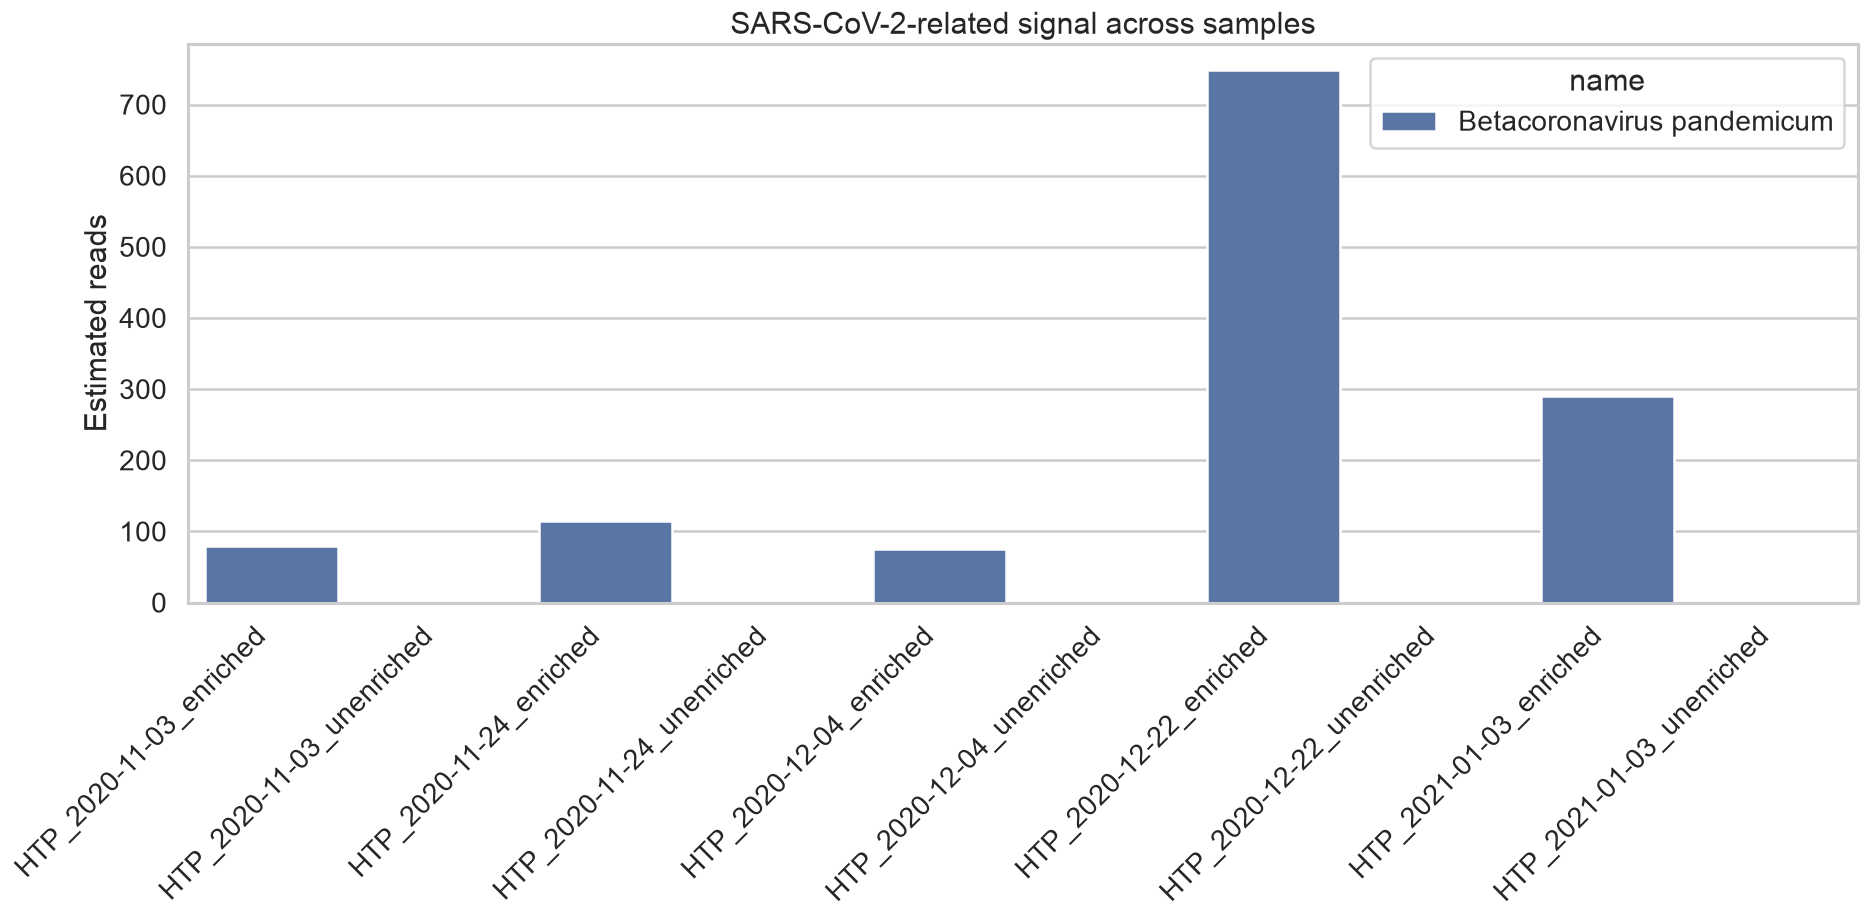

In [101]:
# SARS-CoV-2-like abundance plot
if not sars.empty:
    plt.figure(figsize=(16, 8))
    sns.barplot(
        data=sars.sort_values(["date", "sample"]),
        x="sample",
        y="reads",
        hue="name"
    )
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Estimated reads")
    plt.xlabel("")
    plt.title("SARS-CoV-2-related signal across samples")
    plt.tight_layout()
    plt.show()
else:
    print("No SARS-CoV-2-related taxa found in viral_taxa_summary.tsv")

> The only coronavirus-related taxonomic signal recovered in these data was low-abundance assignment to **Betacoronavirus pandemicum**, a current NCBI species name associated with the SARS-related coronavirus lineage. Because this signal was sparse, these samples did not provide a strong basis for dedicated SARS-CoV-2 SNV analysis.

### SARS-CoV-2 Kraken2/Bracken section MCQ

__Your `Kraken2`/`Bracken` results show low to moderate numbers of reads assigned to Betacoronaviruses in a subset of samples, but the signal is far weaker than for abundant plant tobamoviruses. Why is it still useful to analyze SARS-CoV-2 separately from the broader wastewater virome at this stage?__

> A) To assess whether SARS-CoV-2 is detectable at all and whether its abundance is high enough to justify more targeted alignment-based SNV analysis, even though lineage-level inference is not reliable from `Kraken2`/`Bracken` alone.  
> B) Because `Kraken2`/`Bracken` classifications are sufficient to determine exact SARS-CoV-2 lineages without any read alignment.  
> C) Because focusing on SARS-CoV-2 allows you to skip host filtering and library QC.  
> D) Because separating SARS-CoV-2 from other viruses automatically increases its relative abundance in every sample.

### Targeted SARS-CoV-2 Analysis

> Kraken/Bracken suggested coronavirus-related signal in a subset of samples, but taxonomic classification alone was not sufficient to determine whether those reads represented usable SARS-CoV-2 genomic coverage. Because SNV analysis requires direct evidence of genome-level coverage, host-filtered reads were aligned to the SARS-CoV-2 reference genome (NC_045512.2).
>
> This step was used to quantify SARS-CoV-2 mapped reads, mean genome depth, and coverage breadth at >=1x and >=10x. These metrics provide a more specific assessment of whether the enrichment protocol increased recoverable SARS-CoV-2 signal and whether any samples had sufficient coverage to justify downstream SNV analysis.

In [81]:
# load new analysis summary table
sars_align = pd.read_csv(SUMMARY_DIR / "sars_cov2_alignment_summary.tsv", sep="\t")
sars_align["date"] = pd.to_datetime(sars_align["date"])
sars_align = sars_align.sort_values(["date", "treatment"])
display(sars_align)

,sample,site,date,treatment,is_enriched,mapped_reads_sars_cov2,reference_length,mean_depth_sars_cov2,breadth_1x_sars_cov2,breadth_10x_sars_cov2
0,HTP_2020-11-03_enriched,HTP,2020-11-03,enriched,True,160,29903,0.519078,0.261512,0.001438
1,HTP_2020-11-03_unenriched,HTP,2020-11-03,unenriched,False,0,29903,0.000000,0.000000,0.000000
2,HTP_2020-11-24_enriched,HTP,2020-11-24,enriched,True,235,29903,0.736749,0.316657,0.003344
3,HTP_2020-11-24_unenriched,HTP,2020-11-24,unenriched,False,0,29903,0.000000,0.000000,0.000000
4,HTP_2020-12-04_enriched,HTP,2020-12-04,enriched,True,158,29903,0.496606,0.215229,0.000000
5,HTP_2020-12-04_unenriched,HTP,2020-12-04,unenriched,False,0,29903,0.000000,0.000000,0.000000
6,HTP_2020-12-22_enriched,HTP,2020-12-22,enriched,True,1544,29903,4.909808,0.855098,0.141156
7,HTP_2020-12-22_unenriched,HTP,2020-12-22,unenriched,False,5,29903,0.013611,0.012072,0.000000
8,HTP_2021-01-03_enriched,HTP,2021-01-03,enriched,True,608,29903,1.898940,0.578236,0.027890
9,HTP_2021-01-03_unenriched,HTP,2021-01-03,unenriched,False,0,29903,0.000000,0.000000,0.000000


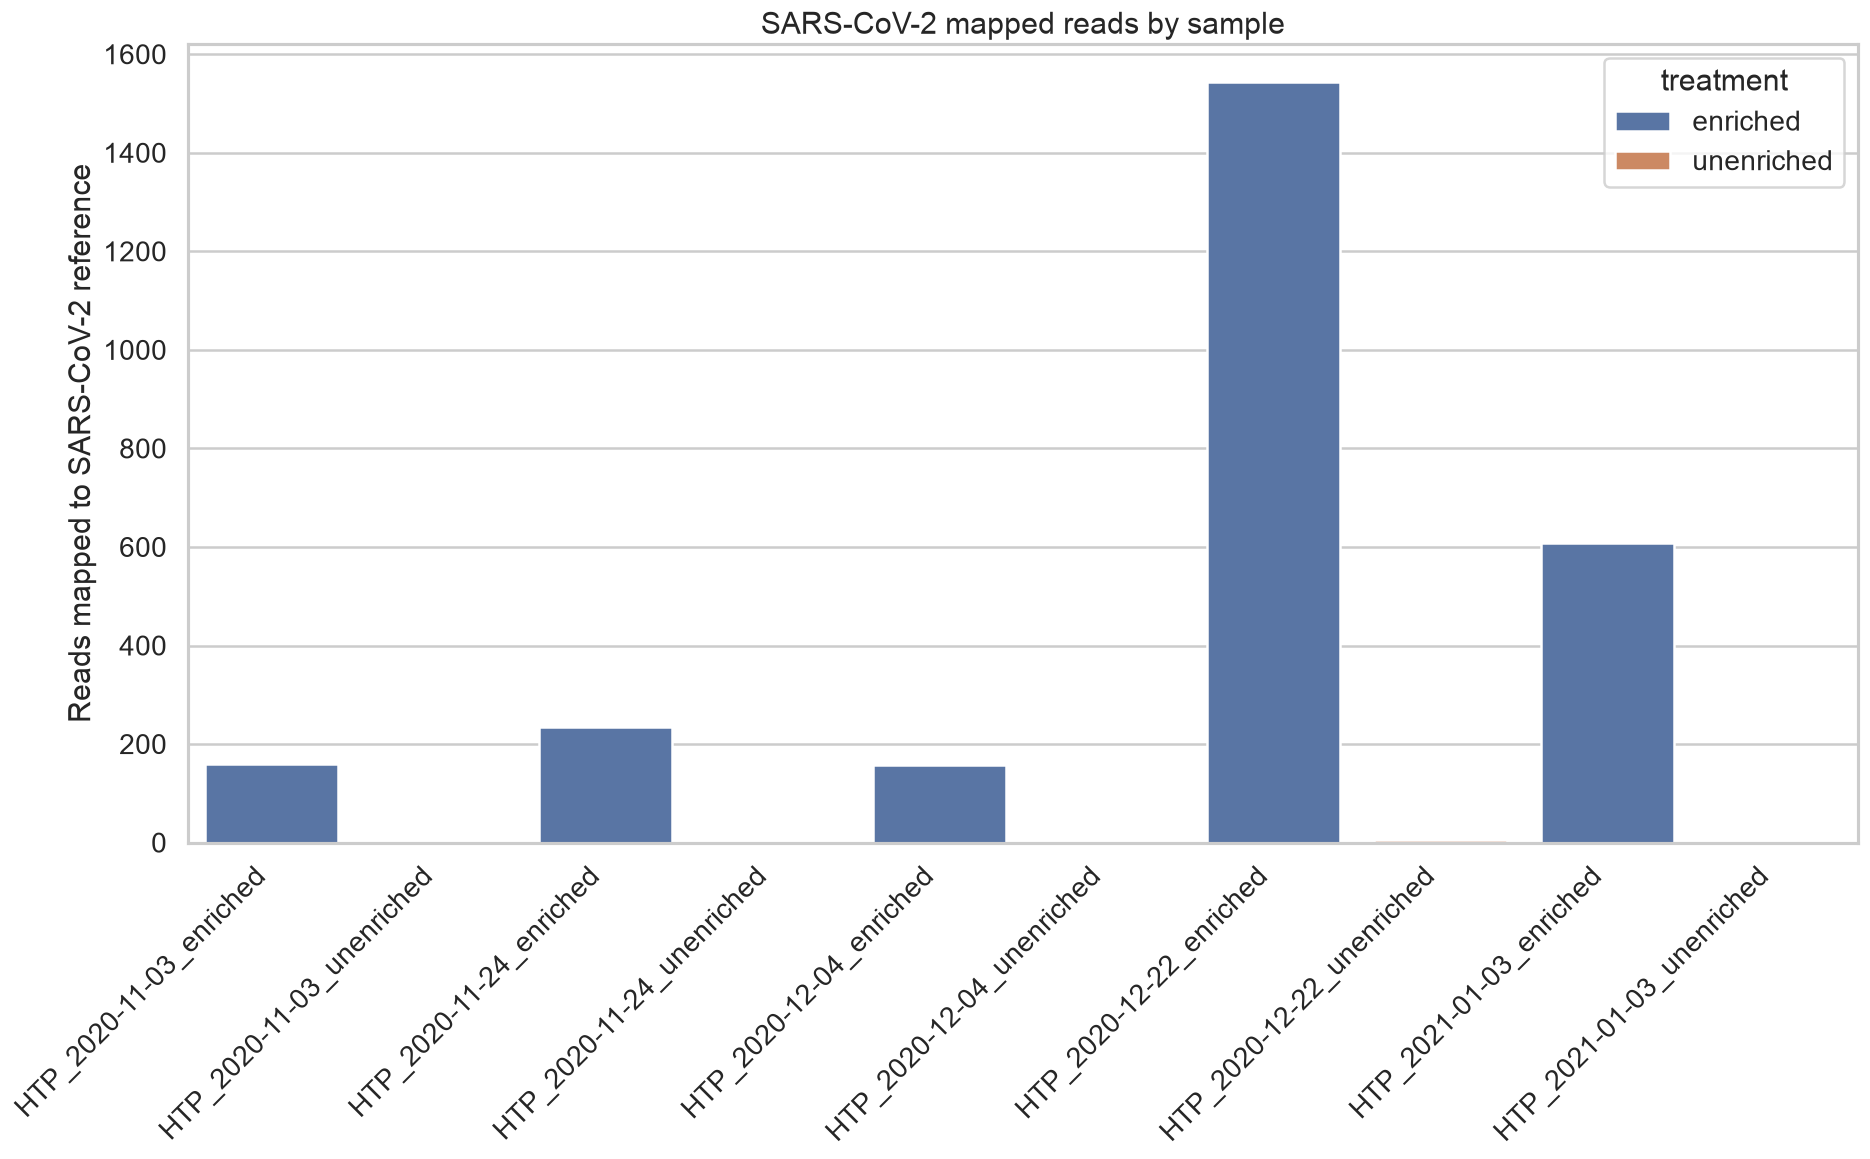

In [83]:
# plot mapped reads
plt.figure(figsize=(16, 10))
sns.barplot(
    data=sars_align,
    x="sample",
    y="mapped_reads_sars_cov2",
    hue="treatment"
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Reads mapped to SARS-CoV-2 reference")
plt.xlabel("")
plt.title("SARS-CoV-2 mapped reads by sample")
plt.tight_layout()
plt.show()

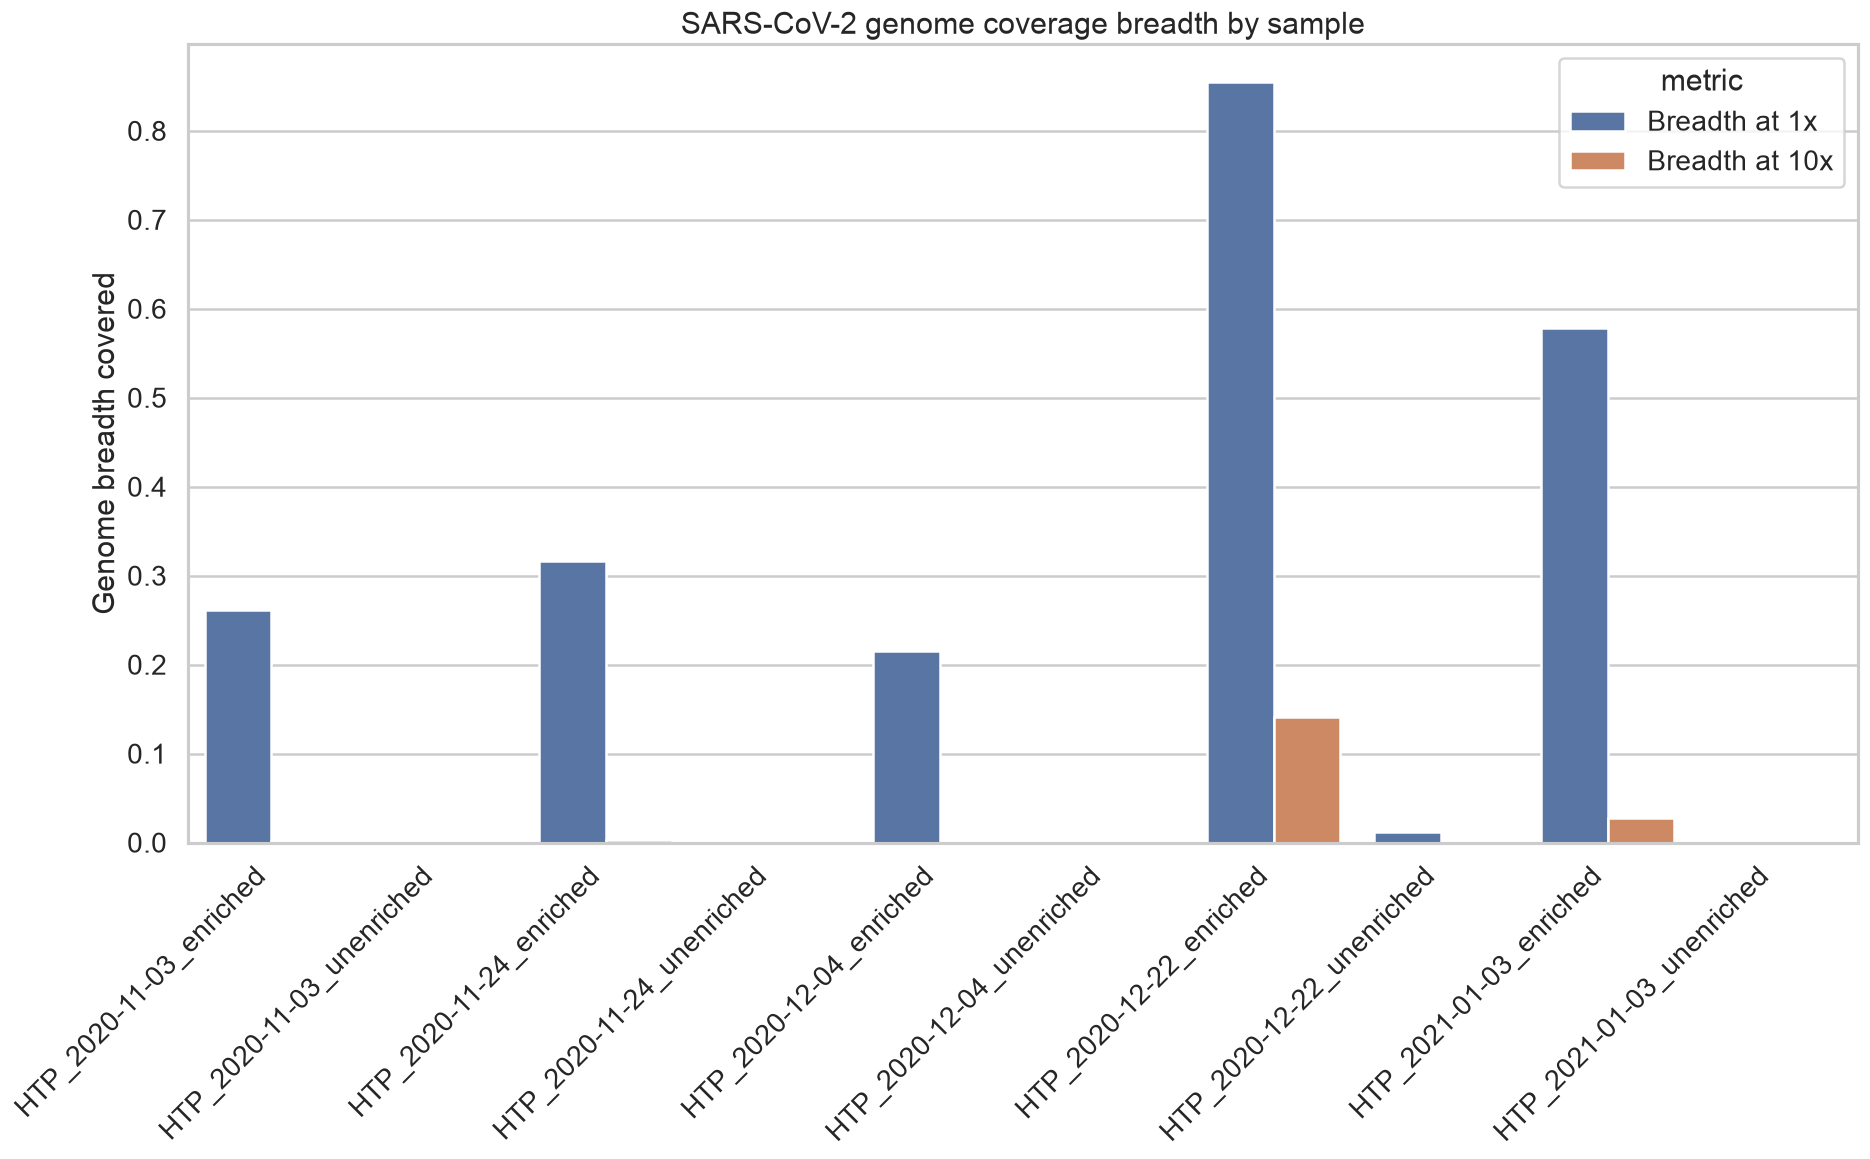

In [85]:
# Plot coverage breadth
breadth_long = sars_align.melt(
    id_vars=["sample", "date", "treatment"],
    value_vars=["breadth_1x_sars_cov2", "breadth_10x_sars_cov2"],
    var_name="metric",
    value_name="breadth"
)

breadth_long["metric"] = breadth_long["metric"].map({
    "breadth_1x_sars_cov2": "Breadth at 1x",
    "breadth_10x_sars_cov2": "Breadth at 10x"
})

plt.figure(figsize=(16, 10))
sns.barplot(
    data=breadth_long,
    x="sample",
    y="breadth",
    hue="metric"
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Genome breadth covered")
plt.xlabel("")
plt.title("SARS-CoV-2 genome coverage breadth by sample")
plt.tight_layout()
plt.show()

### Interpretation

> Direct alignment of host-filtered reads to the SARS-CoV-2 reference (NC_045512.2) showed consistent enrichment of SARS-CoV-2 signal in enriched libraries compared to unenriched libraries. Enriched samples typically had hundreds to ~1500 mapped reads, mean coverage depths between ~0.5 and ~5×, and genome coverage breadth at ≥1× between ~0.2 and ~0.86. In contrast, unenriched samples had zero or near-zero mapped reads and negligible coverage.

> These results confirm that the targeted viral enrichment step substantially increases recoverable SARS-CoV-2 signal. However, most samples still have limited coverage breadth at ≥10×, suggesting that robust SNV analysis is feasible only for the highest-coverage enriched samples (e.g., HTP_2020-12-22_enriched), and should be interpreted cautiously for the rest.

### SARS-CoV2 MCQ

__Based on the SARS-CoV-2 alignment summary, which statement is best supported?__

> A) Enriched libraries consistently show higher SARS-CoV-2 read counts and coverage breadth than unenriched libraries.  
> B) Unenriched libraries have sufficient coverage for robust SARS-CoV-2 SNV analysis.  
> C) SARS-CoV-2 signal is absent from all samples.  
> D) Alignment to the SARS-CoV-2 reference is unnecessary given the Kraken results.

### Exploratory SARS-CoV-2 SNV calls in HTP_2020-12-22_enriched

> To illustrate that SNV analysis is technically feasible in the highest-coverage enriched sample, an exploratory variant-calling step was applied to the HTP_2020-12-22_enriched alignment. Variants were called using bcftools mpileup followed by bcftools call against the Wuhan-Hu-1 SARS-CoV-2 reference (NC_045512.2). The resulting VCF contains a modest number of sites where the sample sequence differs from the reference, along with per-site depth and allele support metrics (e.g., DP and DP4).

> Most candidate variants in this sample are supported by multiple reads and high mapping quality (MQ ≈ 60), but genotypes are reported in diploid form (0/1 or 1/1) because bcftools uses diploid models by default. Given the limited overall depth and partial coverage in this metatranscriptomic wastewater library, these calls should be interpreted as an exploratory indication of SARS-CoV-2 sequence variation rather than as a comprehensive or clinical-grade variant profile.

In [93]:
# show some lines of the results
vcf_path = SARS_DIR / "variants" / "HTP_2020-12-22_enriched.vcf.gz"

# Show a few variant records (excluding header)
!bcftools view -H "{vcf_path}" | head

# Count how many variants were called
!bcftools view -H "{vcf_path}" | wc -l

[W::bcf_hdr_check_sanity] MQ should be declared as Type=Float
NC_045512.2	734	.	T	C	30.4183	.	DP=2;SGB=-0.379885;MQ0F=0;AC=2;AN=2;DP4=0,0,1,0;MQ=60	GT:PL:AD	1/1:60,3,0:0,1
NC_045512.2	773	.	A	C	14.7332	.	DP=7;SGB=-0.379885;RPBZ=-1.34164;MQBZ=0;MQSBZ=0;BQBZ=0.942809;SCBZ=0;MQ0F=0;AC=1;AN=2;DP4=1,2,1,0;MQ=60	GT:PL:AD	0/1:48,0,127:3,1
NC_045512.2	804	.	G	C	14.3183	.	DP=8;SGB=-0.379885;RPBZ=0.447214;MQBZ=0;MQSBZ=0;BQBZ=0;SCBZ=0;MQ0F=0;AC=1;AN=2;DP4=3,0,0,1;MQ=60	GT:PL:AD	0/1:48,0,140:3,1
NC_045512.2	1883	.	G	A	3.31579	.	DP=12;SGB=-0.379885;RPBZ=-0.883452;MQBZ=0;MQSBZ=0;BQBZ=1;SCBZ=0;MQ0F=0;AC=1;AN=2;DP4=2,5,1,0;MQ=60	GT:PL:AD	0/1:36,0,241:7,1
NC_045512.2	2745	.	A	C	38.1245	.	DP=8;VDB=0.0221621;SGB=-0.511536;RPBZ=-2.36643;MQBZ=0;MQSBZ=0;BQBZ=0;SCBZ=0;MQ0F=0;AC=1;AN=2;DP4=3,2,3,0;MQ=60	GT:PL:AD	0/1:71,0,138:5,3
NC_045512.2	3037	.	C	T	62.4147	.	DP=3;VDB=0.0221621;SGB=-0.511536;MQ0F=0;AC=2;AN=2;DP4=0,0,0,3;MQ=60	GT:PL:AD	1/1:92,9,0:0,3
NC_045512.2	3461	.	A	T	3.62418	.	DP=11;VDB=0.02;SGB=-0.453

### Interpretation of SARS-CoV-2 SNV calls

> The exploratory bcftools analysis for HTP_2020-12-22_enriched yielded 64 candidate SARS-CoV-2 variants relative to the Wuhan-Hu-1 reference (NC_045512.2). This call set is consistent with the coverage metrics for this sample (mean depth ~5×, ~86% of the genome covered at ≥1× and ~14% at ≥10×), and demonstrates that SNV calling is technically feasible in the highest-coverage enriched library.

> However, the overall depth and fraction of the genome covered at ≥10× remain relatively modest for a metatranscriptomic wastewater dataset. As a result, these variants are best interpreted as an exploratory indication of SARS-CoV-2 sequence variation present in this enriched sample, rather than as a comprehensive or lineage-resolved variant profile. The main conclusion from this step is that the enrichment protocol can recover enough SARS-CoV-2 signal to support basic reference-based variant calling in at least one sample, while broader, more detailed SNV analyses would require deeper and more uniform coverage.

> No attempt was made to assign these variants to specific SARS-CoV-2 lineages, because the depth and coverage in this single metatranscriptomic sample are insufficient for robust lineage deconvolution.

### SARS-CoV-2 SNV MCQ

__What is the main scientific takeaway from the exploratory SARS-CoV-2 SNV analysis of HTP_2020-12-22_enriched?__

> A) The sample has sufficient coverage to fully characterize SARS-CoV-2 lineage diversity in the sewershed.  
> B) Enrichment can recover enough SARS-CoV-2 signal in at least one sample to support basic reference-based SNV calling, but coverage is still limited for comprehensive variant profiling.  
> C) SNV analysis showed that unenriched samples contain more SARS-CoV-2 variants than enriched samples.  
> D) The presence of 64 variants alone is adequate evidence for precise clinical interpretation of SARS-CoV-2 infection dynamics.

## Reproducibility

> All preprocessing and summary-table generation were performed with Snakemake. This notebook reads workflow outputs from `results/summary/` and `results/taxonomy/merged/`, making it executable both interactively in JupyterLab and non-interactively through the downstream Snakemake report-render rule. The complete, version-controlled workflow and notebook are available in the GitHub repository: [https://github.com/shigdon/wastewater-viromics-takehome/tree/main](https://github.com/shigdon/wastewater-viromics-takehome/tree/main).